# LOAD LIBRARIES

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from diive.core.io.files import save_parquet, load_parquet
from datetime import datetime
import os
import sys
import shap
# Custom utilities
# Add the parent directory (project root) to sys.path
# "Go up two levels" and add to path
sys.path.append(os.path.abspath('../../../')) 
from src.config import PERIOD_START, PERIOD_END, select_period
from src.gapfilling_utils import (
    fit_gapfill_ts,
    build_df_for_parcel,
    apply_gapfill_ts,
    plot_gapfill_dashboard,
    merge_gapfill_results
)

# CONFIGURATION

In [2]:
START_DATE, END_DATE = PERIOD_START, PERIOD_END  # dataset period, see src/config.py
TARGET_FLUX = 'FN2O'
RAND_ERR_COL = "FN2O_RANDUNC_HF"  # EddyPro random uncertainty col
MODEL_TYPE = 'XGBoost'  # Options: 'RandomForest' or 'XGBoost'
PARCEL_CERTAIN = True
LOG_TRANSFORM = False
UNDERSAMPLE = False
ADD_TRT = True
SHAP_CHECK = True

# LOAD DATA

In [3]:
data_main = fluxes = load_parquet(filepath=r"82.1.1_GapFillingDataset.parquet")
data_main = select_period(data_main, timestamp='middle')

# Make a copy of the original data for later use
maindf = data_main.copy()

# Keep only data where we are sure about parcel attribution
if PARCEL_CERTAIN:
    data_main = data_main[data_main['parcel_certainty'] == 'certain'].copy()
    print('\nKeeping only data when we are highly confident on the parcel attribution')
else:
    print('\nKeeping also data from mixed parcel contribution')

data_main

Loaded .parquet file 82.1.1_GapFillingDataset.parquet (0.324 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 
select_period: kept 14928 of 14928 records (2023-10-17 00:15:00 to 2024-08-22 23:45:00, timestamp=middle)

Keeping only data when we are highly confident on the parcel attribution


,NEE_L3.3_CUT_50_QCF_footprint_gfXGBoost,GPP_NT_CUT_50_QCF_footprint_gfXGBoost,FN2O_L3.3_CUT_16_QCF,FN2O_L3.3_CUT_50_QCF,FN2O_L3.3_CUT_84_QCF,FN2O_L3.3_CUT_16_QCF0,FN2O_L3.3_CUT_50_QCF0,FN2O_L3.3_CUT_84_QCF0,parcel,parcel_certainty,trt,FN2O_RANDUNC_HF,SW_IN_POT,prec,ta,...,wfps_0.15_gfXG_diff24h,wfps_0.3_gfXG_diff6h,wfps_0.3_gfXG_diff12h,wfps_0.3_gfXG_diff24h,n_decay_linear,n_decay_logistic,n_decay_exponential,n_decay_lognormal,n_decay_timed,timesince_fert,timesince_fert_min,timesince_fert_org,can_height,cropN,id
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-07 15:45:00,0.123126,1.196652,NaN,NaN,NaN,NaN,NaN,NaN,B,certain,1.0,0.205045,267.16400,0.0,7.366667,...,0.031227,0.385963,0.705085,0.129544,0.000000,0.000000,2.280252,1.041116,29.0,22.0,30.0,22.0,0.188254,5.153249,1039
2023-11-07 16:15:00,1.440639,-0.121658,0.324973,0.324973,0.324973,0.324973,0.324973,0.324973,B,certain,1.0,0.124789,168.35800,0.0,7.300000,...,0.022161,0.321719,0.557017,0.072530,0.000000,0.000000,2.274546,1.037818,29.0,22.0,30.0,22.0,0.188641,5.153570,1040
2023-11-07 17:15:00,2.060704,-0.782134,0.339963,0.339963,0.339963,0.339963,0.339963,0.339963,B,certain,1.0,0.264532,3.38364,0.5,6.600000,...,0.029544,0.798931,0.793294,0.894488,0.000000,0.000000,2.263177,1.031258,29.0,22.0,30.0,22.0,0.189415,5.154212,1042
2023-11-07 17:45:00,1.999698,-0.715234,-0.983566,-0.983566,-0.983566,-0.983566,-0.983566,-0.983566,B,certain,1.0,0.344428,0.00000,0.2,6.633333,...,0.435220,0.764205,0.910265,0.877980,0.000000,0.000000,2.257514,1.027996,29.0,22.0,30.0,22.0,0.189803,5.154534,1043
2023-11-07 18:15:00,1.908674,-0.638819,-0.064456,-0.064456,-0.064456,-0.064456,-0.064456,-0.064456,B,certain,1.0,0.172716,0.00000,0.5,6.366667,...,0.327660,0.897999,1.085670,1.031942,0.000000,0.000000,2.251865,1.024747,29.0,22.0,30.0,22.0,0.190191,5.154856,1044
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-22 21:45:00,5.789159,-1.174224,NaN,NaN,NaN,NaN,NaN,NaN,B,certain,1.0,0.246469,0.00000,0.0,15.870000,...,-1.456268,-0.031887,-0.371716,-0.464268,184.456349,187.286349,174.585550,12.443672,188.0,1.0,30.0,1.0,0.000000,0.000000,14923
2024-08-22 22:15:00,5.719062,-1.229992,2.623038,2.623038,NaN,NaN,NaN,NaN,B,certain,1.0,0.636039,0.00000,0.0,15.160000,...,-1.399429,-0.000719,-0.361714,-0.454507,184.269841,187.279204,173.906660,14.317380,188.0,1.0,30.0,1.0,0.000000,0.000000,14924
2024-08-22 22:45:00,5.507258,-1.028798,1.743544,1.743544,1.743544,NaN,NaN,NaN,B,certain,1.0,0.343247,0.00000,0.0,15.100000,...,-1.435013,0.009201,-0.350463,-0.453738,184.083333,187.271988,173.230410,16.309472,188.0,1.0,30.0,1.0,0.000000,0.000000,14925


# SELECT FEATURES

In [4]:
# Import the best features
path = 'best_features_' + TARGET_FLUX + '_' + MODEL_TYPE + '.txt'
with open(path, 'r') as f:
    selected_features = [line.strip() for line in f]

# Other option is to define the best n features
# n_top = 23
# path = 'ranked_features_' + TARGET_FLUX + '_' + DAY_NIGHT + '_' + MODEL_TYPE + '.txt'
# with open(path, 'r') as f:
#     selected_features = [line.strip() for line in f][:n_top]

# Remove specific variables if you want
#to_remove = ('flux_nee', 'prec')
#selected_features = [c for c in selected_features if not c.startswith(to_remove)]

# selected_features = [
#     'SW_IN_POT',
#     'ppfd',
#     'timesince_soil_preparation',
#     'timesince_sowing',
#     'n_decay_timed',
#     'ts_0.3_gfXG_roll3hmean'
# ]

# If ADD_TRT is True we add the trt variable even if it was not in the best feature set
if ADD_TRT:
    if 'trt' not in selected_features:
        selected_features.append('trt')
    print('\nThe treatment variable (trt) is included in the feature set')
else:
    if 'trt' in selected_features:
        selected_features.remove('trt')
    print('\nThe treatment variable (trt) is not included in the feature set')

selected_features


The treatment variable (trt) is included in the feature set


['GPP_NT_CUT_50_QCF_footprint_gfXGBoost',
 'ta',
 'ts_0.05_gfXG',
 'ts_0.15_gfXG',
 'ts_0.3_gfXG',
 'wfps_0.05_gfXG',
 'wfps_0.15_gfXG',
 'wfps_0.3_gfXG',
 'timesince_soil_preparation',
 'timesince_harvest',
 'timesince_sowing',
 'prec_lag6h',
 'ta_lag6h',
 'ts_0.15_gfXG_lag3h',
 'ts_0.3_gfXG_lag6h',
 'ts_0.3_gfXG_lag9h',
 'wfps_0.05_gfXG_lag3h',
 'wfps_0.05_gfXG_lag6h',
 'wfps_0.05_gfXG_lag9h',
 'wfps_0.3_gfXG_lag3h',
 'wfps_0.3_gfXG_lag6h',
 'prec_roll3hsum',
 'prec_roll6hsum',
 'prec_roll9hsum',
 'ta_roll3hmean',
 'ts_0.05_gfXG_roll6hmean',
 'ts_0.15_gfXG_roll6hmean',
 'ts_0.15_gfXG_roll9hmean',
 'ts_0.3_gfXG_roll3hmean',
 'ts_0.3_gfXG_roll6hmean',
 'ts_0.3_gfXG_roll9hmean',
 'wfps_0.05_gfXG_roll3hmean',
 'wfps_0.3_gfXG_roll3hmean',
 'wfps_0.3_gfXG_roll9hmean',
 'prec_lag3h_roll6hsum',
 'prec_lag3h_roll9hsum',
 'prec_lag6h_roll6hsum',
 'prec_lag6h_roll9hsum',
 'prec_lag9h_roll3hsum',
 'prec_lag9h_roll6hsum',
 'ta_lag6h_roll3hmean',
 'ts_0.05_gfXG_lag3h_roll6hmean',
 'ts_0.05_gfXG_la

# SELECT MODEL

In [5]:
# Load hyperparameters from JSON file
path = 'best_hyperparameters_' + TARGET_FLUX + '_' + MODEL_TYPE + '.json'
with open(path, "r") as file:
    hyperparams = json.load(file)

# Print loaded hyperparameters (optional)
print("Loaded Hyperparameters:", hyperparams)

def model_factory():
    if MODEL_TYPE == "RandomForest":
        return RandomForestRegressor(**hyperparams, random_state=42, n_jobs=-1)
    else:
        return XGBRegressor(**hyperparams, random_state=42, n_jobs=-1)

Loaded Hyperparameters: {'colsample_bytree': 0.7380330511289547, 'gamma': 0.17380960724134176, 'learning_rate': 0.008180468148516513, 'max_depth': 8, 'min_child_weight': 1, 'n_estimators': 744, 'subsample': 0.7843115072130903}


# GAP-FILLING

## CUT-16

In [6]:
USTAR_CUT = 'CUT_16'
TARGET = f'{TARGET_FLUX}_L3.3_{USTAR_CUT}_QCF0'
print(f'The target variable is {TARGET}')

The target variable is FN2O_L3.3_CUT_16_QCF0


### MODEL TRAINING

Started training of the gapfilling model and compute gapfilling uncertainty...
  Gap distribution: fitted mixture (cvm distance 18.3690; raw baseline 25.7381)
CV Strategy: artificial gaps in real time; 20 splits; test fractions 0.100-0.101
  Coverage: 603/5148 rows never held out (11.7%); mean times held out 2.00


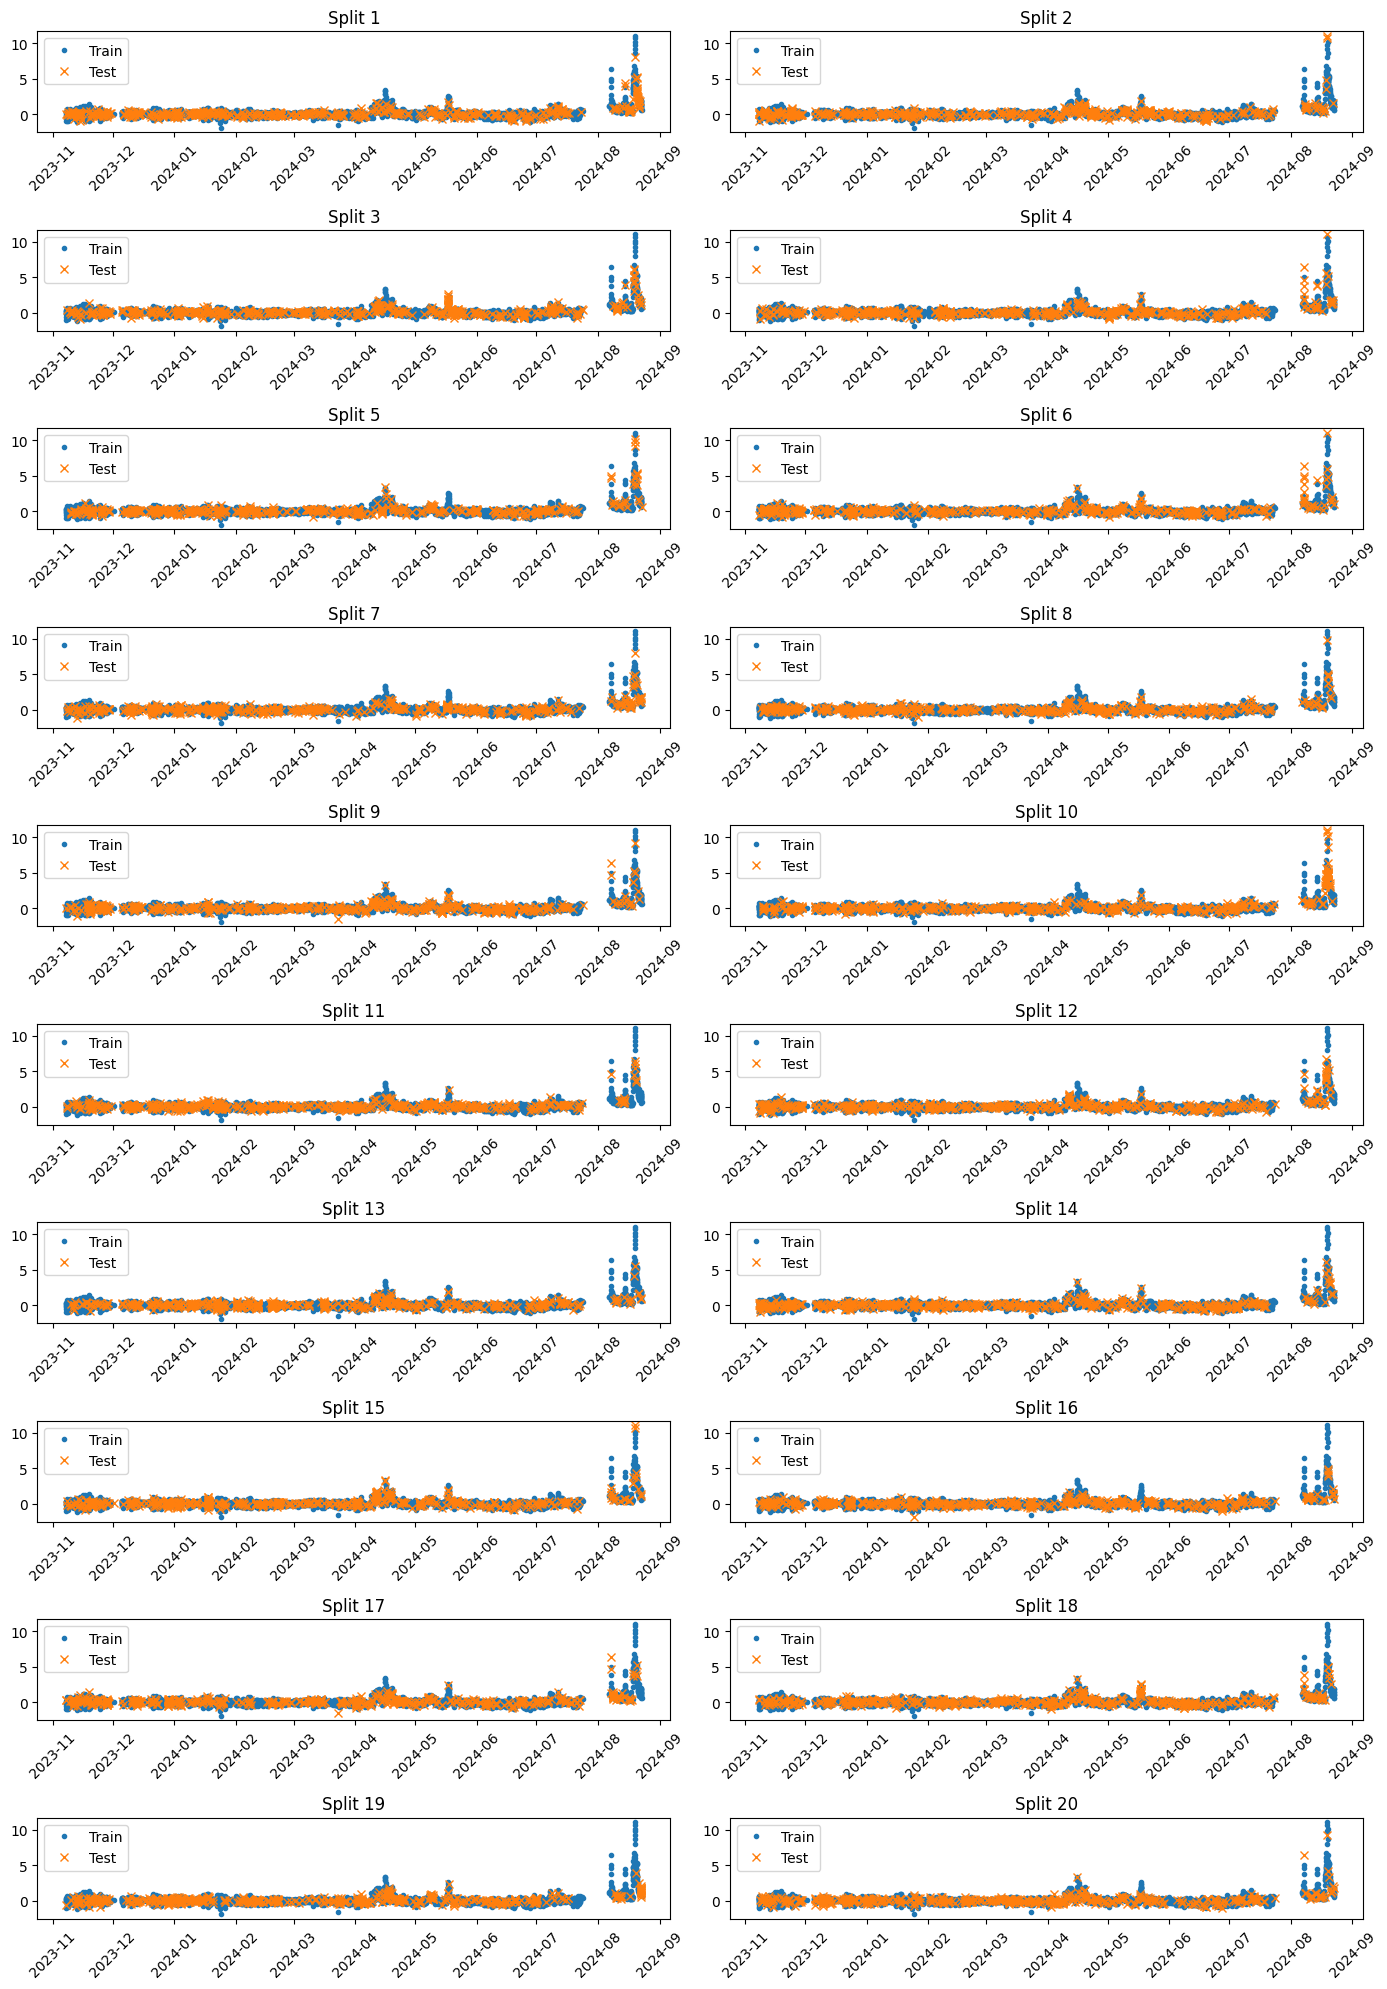

Training CV Ensemble (20 folds) & generating OOF predictions...
----------------------------------------
Gapfilling performance (mean across CV folds):
  Target: FN2O_L3.3_CUT_16_QCF0
  RMSE:   0.2898
  MAE:    0.2000
  R2:     0.8429
----------------------------------------
Fitting final model on full training set...


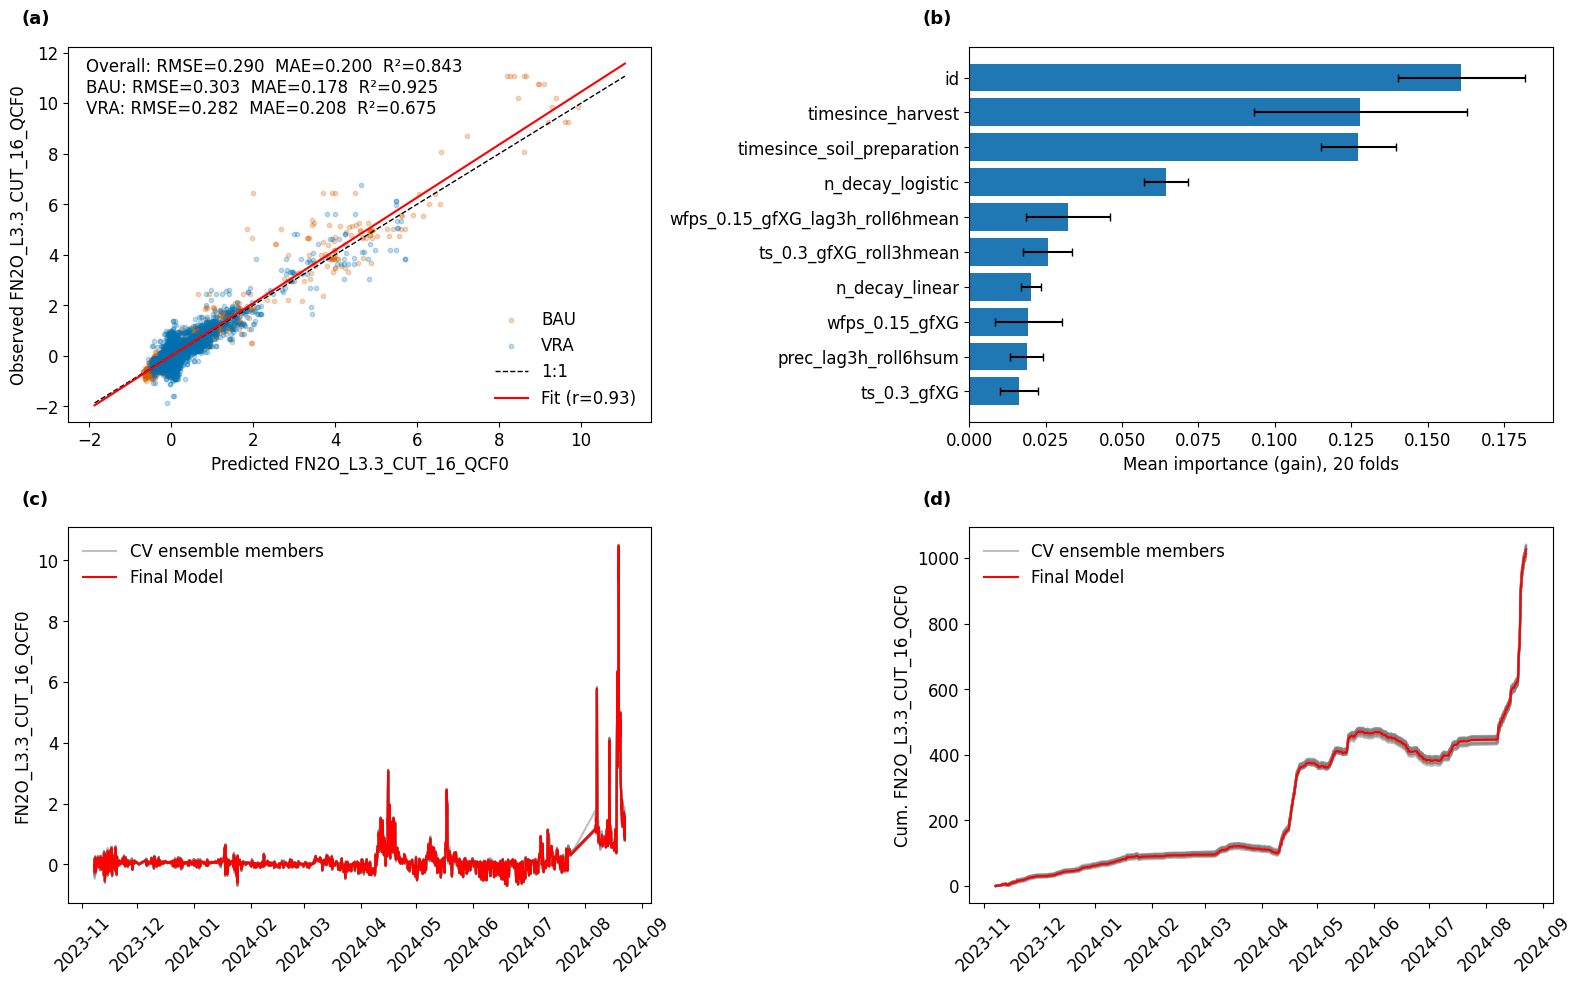

Finished training. Ensemble size (folds): 20

Started training of the gapfilling model for the full footprint and compute gapfilling uncertainty...
  Gap distribution: fitted mixture (cvm distance 20.7248; raw baseline 28.6487)
CV Strategy: artificial gaps in real time; 20 splits; test fractions 0.100-0.102
  Coverage: 722/5870 rows never held out (12.3%); mean times held out 2.01
Training CV Ensemble (20 folds) & generating OOF predictions...
----------------------------------------
Gapfilling performance (mean across CV folds):
  Target: FN2O_L3.3_CUT_16_QCF0
  RMSE:   0.2754
  MAE:    0.1968
  R2:     0.8121
----------------------------------------
Fitting final model on full training set...
Finished training. Ensemble size (folds): 20


In [7]:
# Train ONE model to gapfill --> we train only one model for both parcels and both QCF and QCF0
print("Started training of the gapfilling model and compute gapfilling uncertainty...")
fit = fit_gapfill_ts(
    data_main,
    target_col=TARGET,
    feature_cols=selected_features,
    model_factory=model_factory,
    log_transform=LOG_TRANSFORM,
    undersample=UNDERSAMPLE
)
print(f"Finished training. Ensemble size (folds): {len(fit.ensemble_models)}")

# Train ONE model to gapfill the footprint if only confident assignments were used before
if PARCEL_CERTAIN:
    # we train only one model for both parcels and both QCF and QCF0
    print("\nStarted training of the gapfilling model for the full footprint and compute gapfilling uncertainty...")
    fit_footprint = fit_gapfill_ts(
        maindf,
        target_col=TARGET,
        feature_cols=selected_features,
        model_factory=model_factory,
        log_transform=LOG_TRANSFORM,
        undersample=UNDERSAMPLE,
        plot=False
    )
    print(f"Finished training. Ensemble size (folds): {len(fit_footprint.ensemble_models)}")


### GAPFILLING

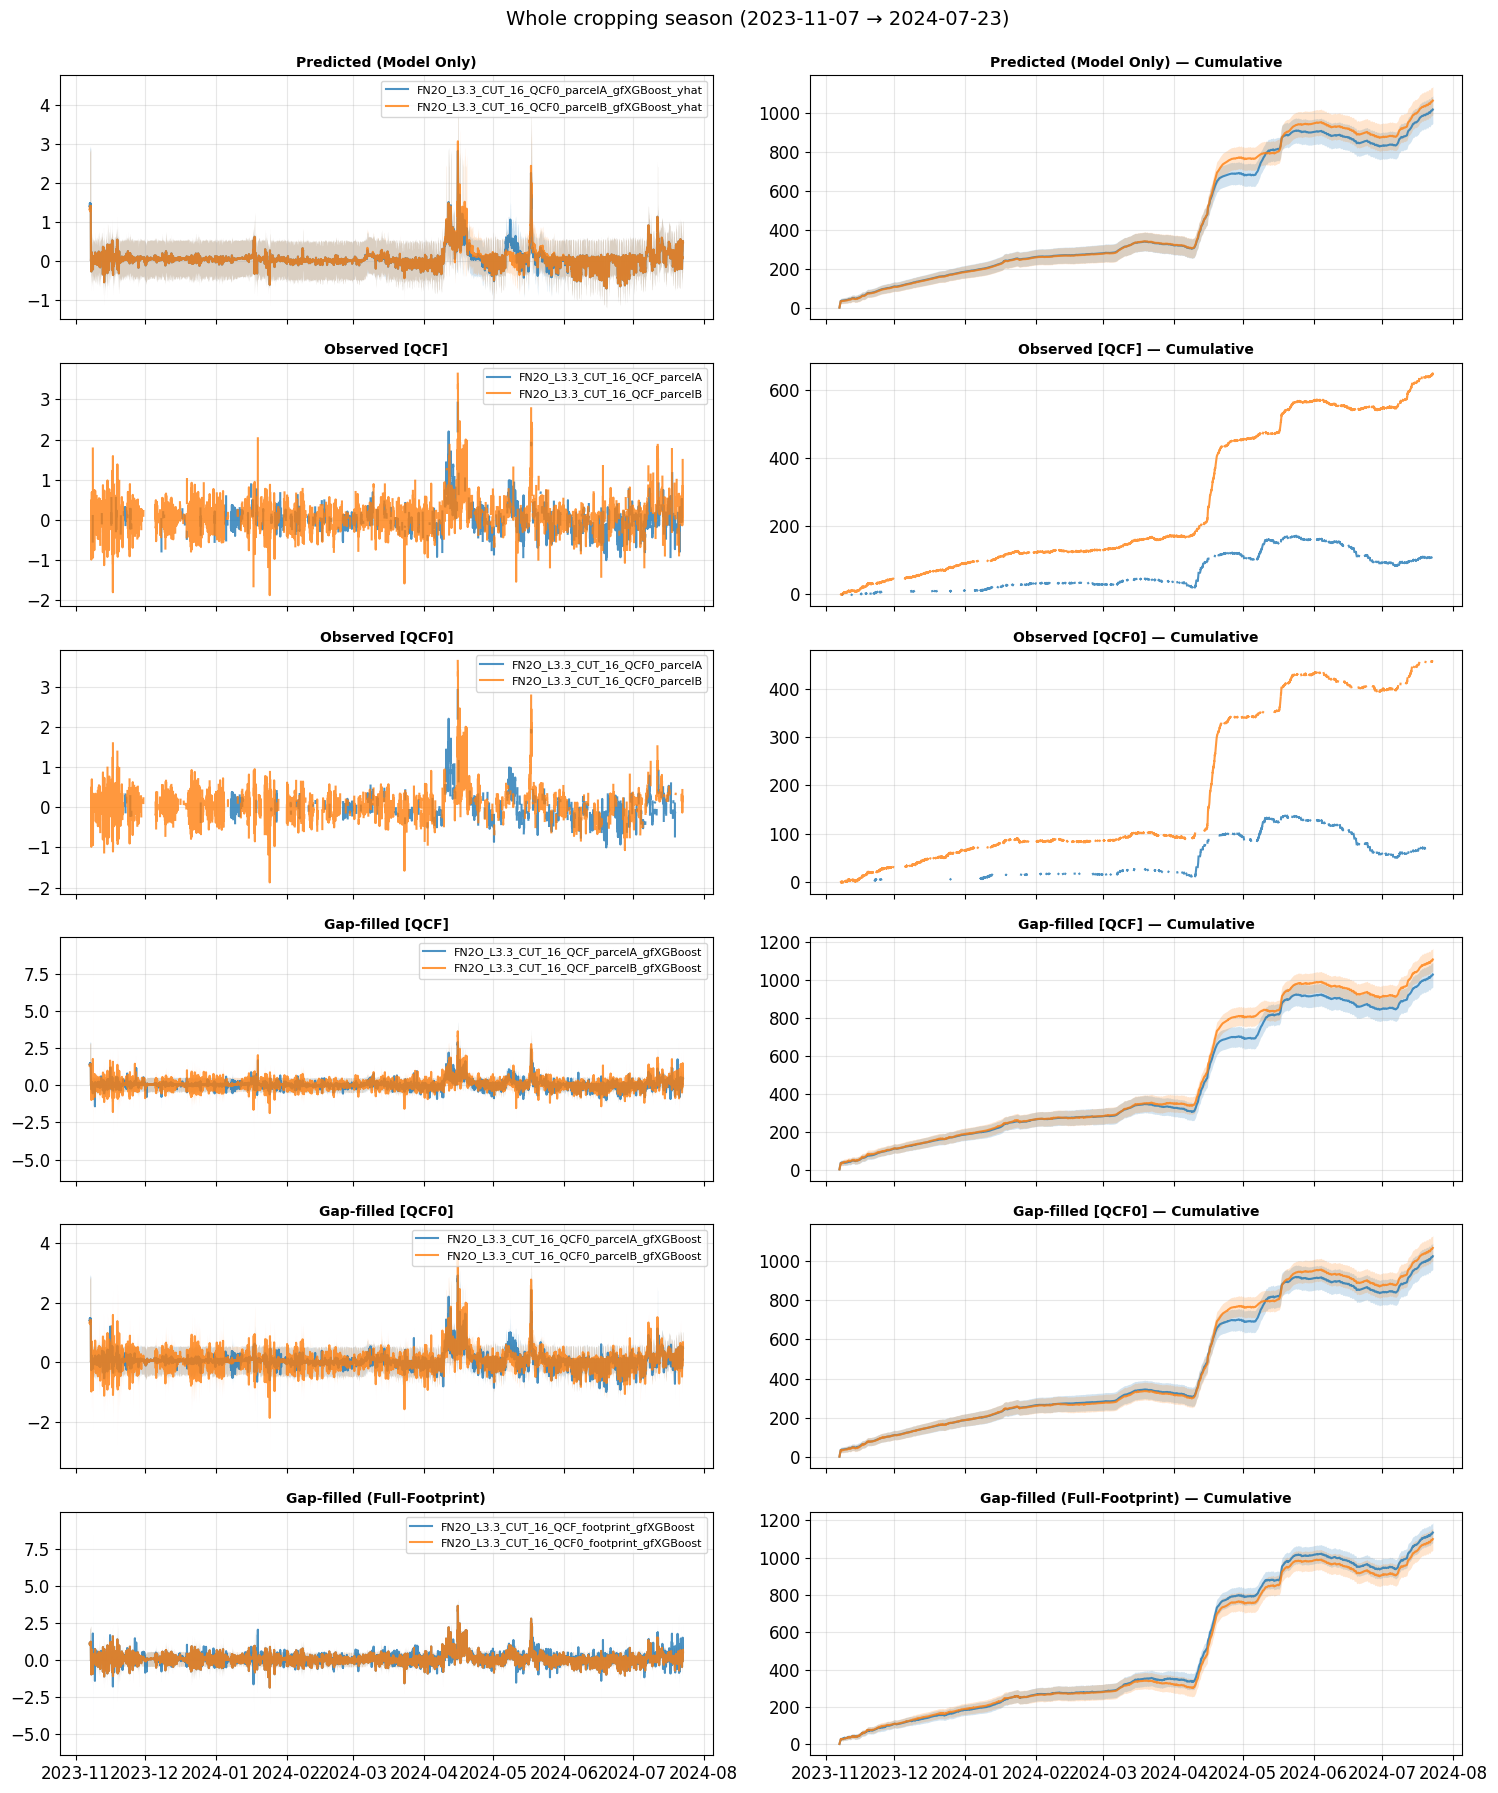

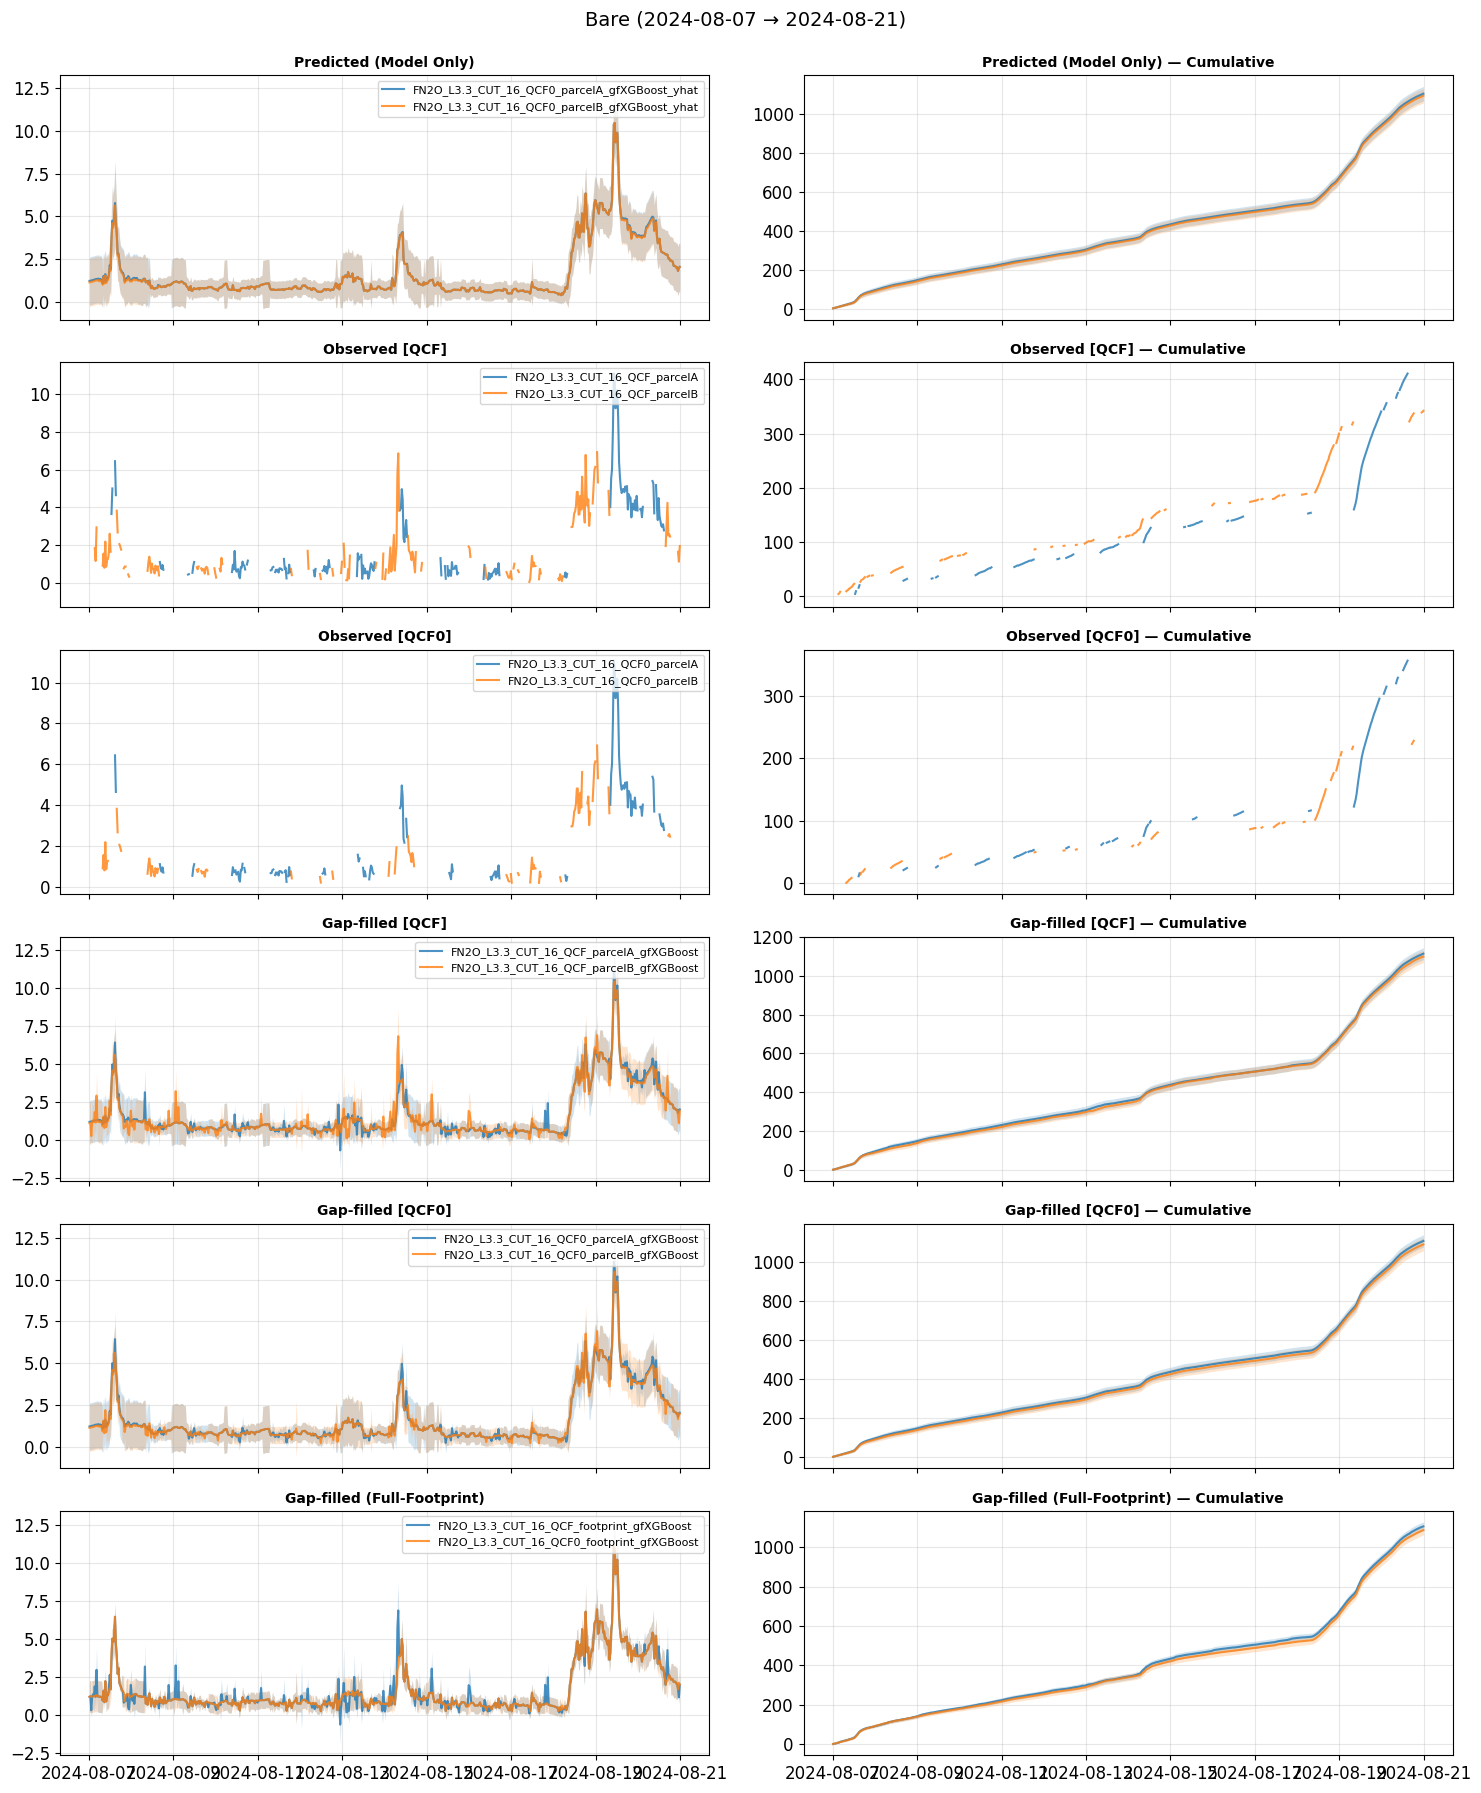

In [8]:
# Setup Views
df_fp = maindf.copy()
df_A  = build_df_for_parcel(maindf, TARGET_FLUX, "A", selected_features, add_trt=ADD_TRT)
df_B  = build_df_for_parcel(maindf, TARGET_FLUX, "B", selected_features, add_trt=ADD_TRT)
views = [
    ("parcelA", df_A, apply_gapfill_ts(df_A, fit), fit),
    ("parcelB", df_B, apply_gapfill_ts(df_B, fit), fit),
]
# Add the Footprint view
if PARCEL_CERTAIN:
    # If we trained a specific model for the footprint, use it
    views.append(("footprint", df_fp, apply_gapfill_ts(df_fp, fit_footprint), fit_footprint))
else:
    # Otherwise, apply the only model we have
    views.append(("footprint", df_fp, apply_gapfill_ts(df_fp, fit), fit))

# Merge Results
df_final, contexts = merge_gapfill_results(
    main_df=maindf,
    views=views,
    target_flux=TARGET_FLUX,      # e.g. "FN2O"
    target=TARGET,
    model_type=MODEL_TYPE,        # e.g. "XGBoost"
    ustar_cut=USTAR_CUT,           # e.g. "CUT_50"
    random_err_col=RAND_ERR_COL
)

# Plot Results
periods = [
    ("2023-11-07", "2024-07-23", "Whole cropping season"),
    ("2024-08-07", "2024-08-21", "Bare")
]
plot_gapfill_dashboard(
    df=df_final,
    periods=periods,
    target_flux=TARGET_FLUX,
    target=TARGET,
    model_type=MODEL_TYPE,
    ustar_cut=USTAR_CUT,
    contexts=contexts
)

# Create a copy of the final dataframe for CUT16
df_CUT16 = df_final.copy()


## CUT-50

In [9]:
USTAR_CUT = 'CUT_50'
TARGET = f'{TARGET_FLUX}_L3.3_{USTAR_CUT}_QCF0'
print(f'The target variable is {TARGET}')

The target variable is FN2O_L3.3_CUT_50_QCF0


### MODEL TRAINING

Started training of the gapfilling model and compute gapfilling uncertainty...
  Gap distribution: fitted mixture (cvm distance 16.4981; raw baseline 22.5873)
CV Strategy: artificial gaps in real time; 20 splits; test fractions 0.100-0.102
  Coverage: 570/4882 rows never held out (11.7%); mean times held out 2.01


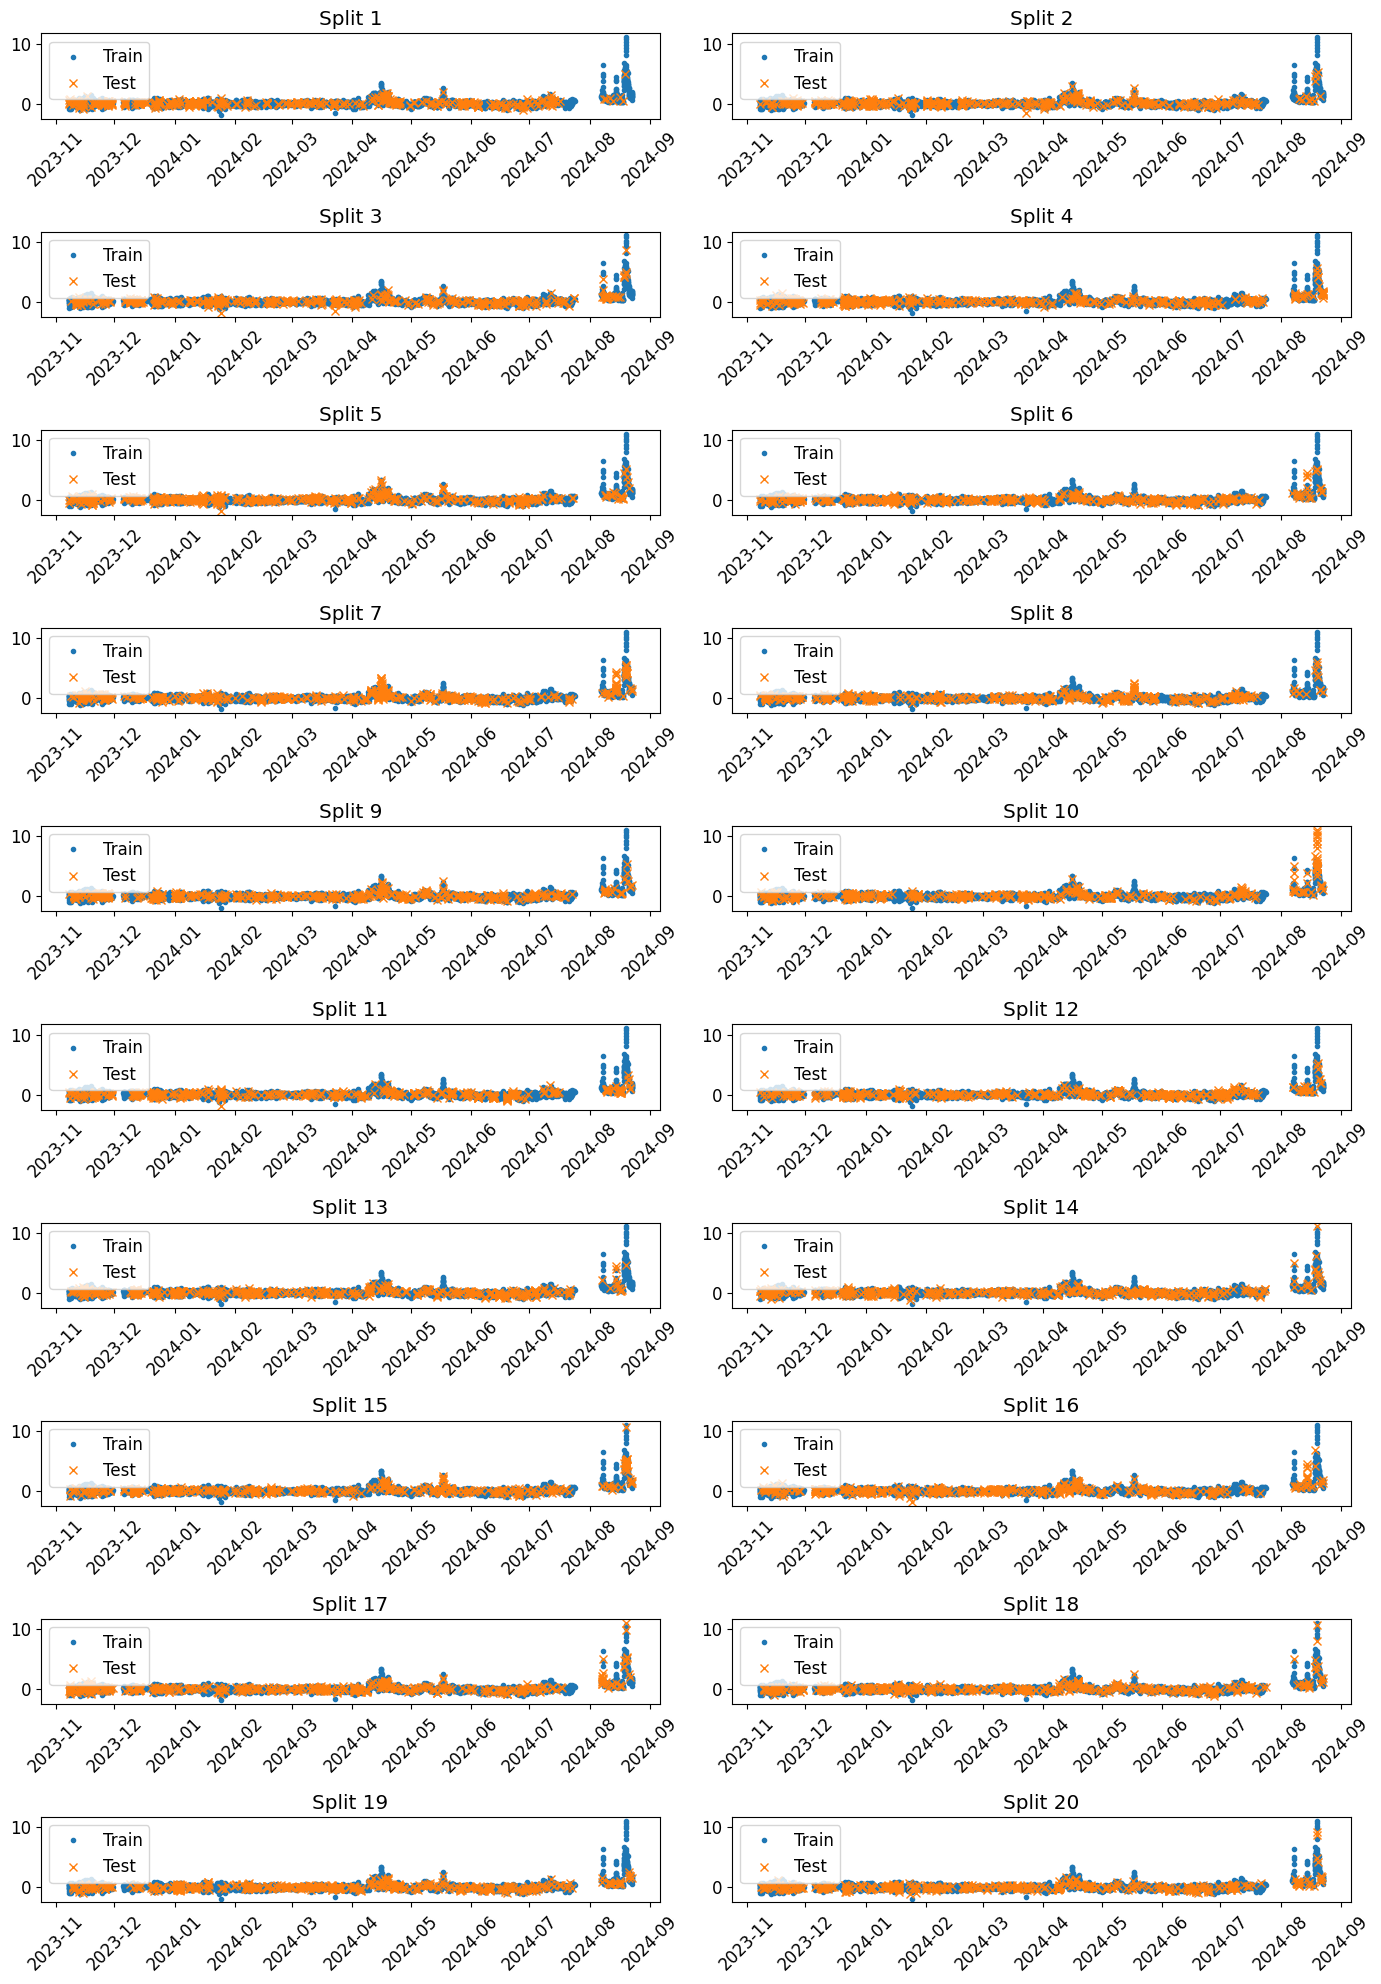

Training CV Ensemble (20 folds) & generating OOF predictions...
----------------------------------------
Gapfilling performance (mean across CV folds):
  Target: FN2O_L3.3_CUT_50_QCF0
  RMSE:   0.3227
  MAE:    0.2139
  R2:     0.7758
----------------------------------------
Fitting final model on full training set...


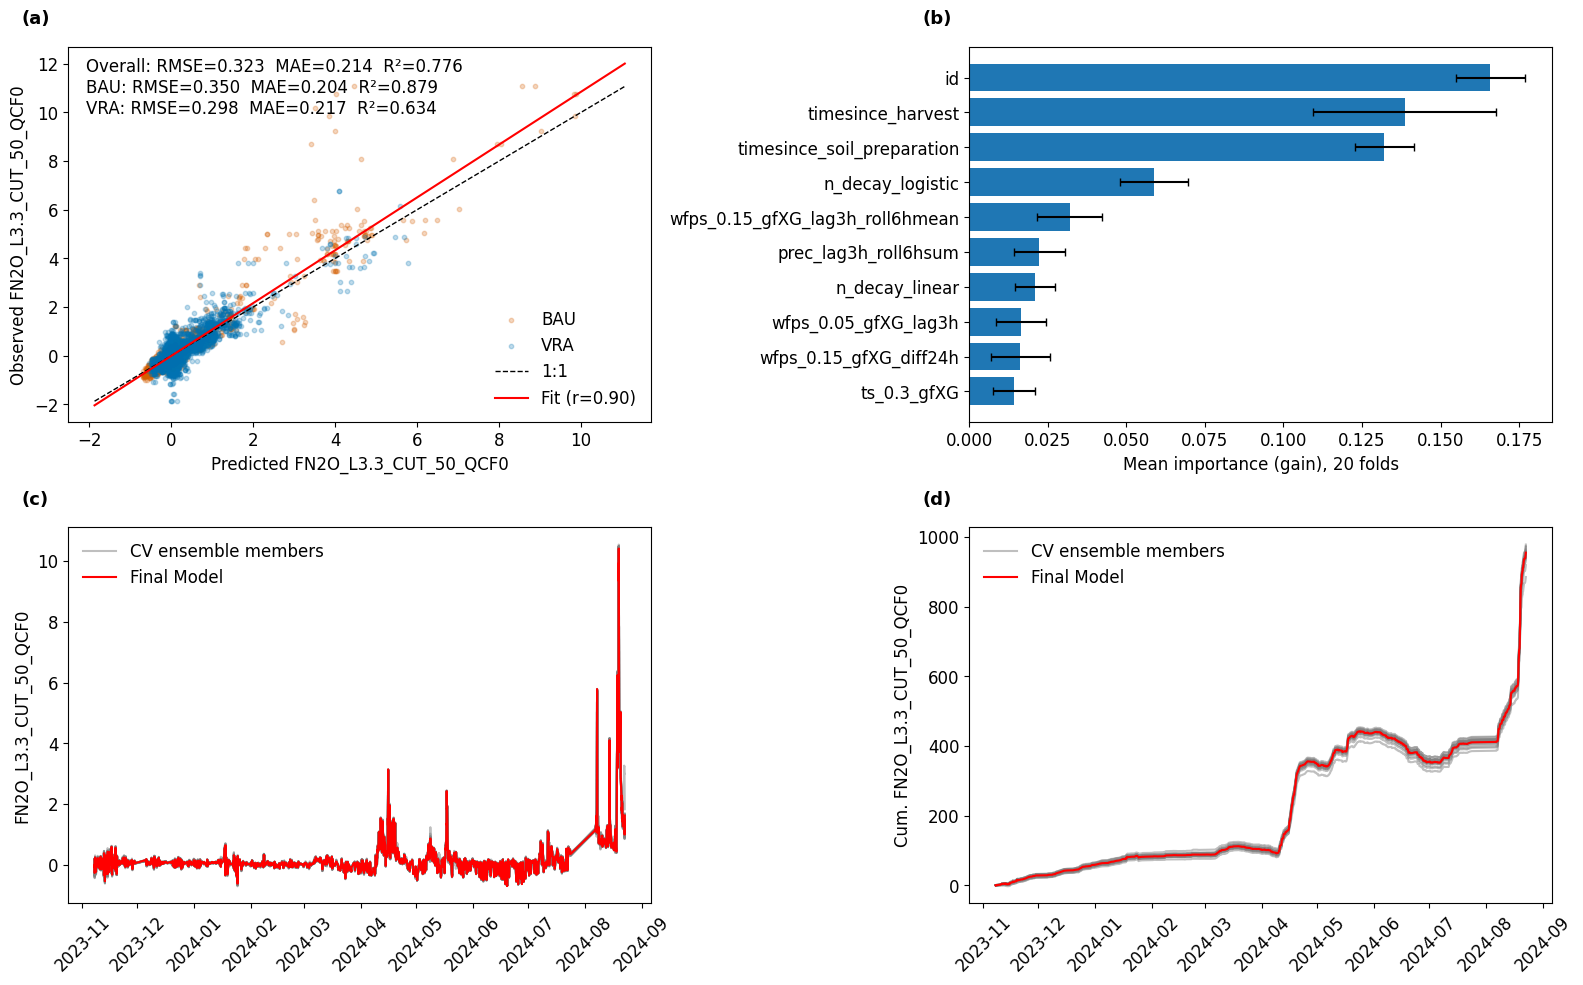

Finished training. Ensemble size (folds): 20

Started training of the gapfilling model for the full footprint and compute gapfilling uncertainty...
  Gap distribution: fitted mixture (cvm distance 18.8343; raw baseline 22.8937)
CV Strategy: artificial gaps in real time; 20 splits; test fractions 0.100-0.103
  Coverage: 625/5532 rows never held out (11.3%); mean times held out 2.01
Training CV Ensemble (20 folds) & generating OOF predictions...
----------------------------------------
Gapfilling performance (mean across CV folds):
  Target: FN2O_L3.3_CUT_50_QCF0
  RMSE:   0.2955
  MAE:    0.2042
  R2:     0.7681
----------------------------------------
Fitting final model on full training set...
Finished training. Ensemble size (folds): 20


In [10]:
# Train ONE model to gapfill --> we train only one model for both parcels and both QCF and QCF0
print("Started training of the gapfilling model and compute gapfilling uncertainty...")
fit = fit_gapfill_ts(
    data_main,
    target_col=TARGET,
    feature_cols=selected_features,
    model_factory=model_factory,
    log_transform=LOG_TRANSFORM,
    undersample=UNDERSAMPLE,
)
print(f"Finished training. Ensemble size (folds): {len(fit.ensemble_models)}")

# Train ONE model to gapfill the footprint if only confident assignments were used before
if PARCEL_CERTAIN:
    # we train only one model for both parcels and both QCF and QCF0
    print("\nStarted training of the gapfilling model for the full footprint and compute gapfilling uncertainty...")
    fit_footprint = fit_gapfill_ts(
        maindf,
        target_col=TARGET,
        feature_cols=selected_features,
        model_factory=model_factory,
        log_transform=LOG_TRANSFORM,
        undersample=UNDERSAMPLE,
        plot=False
    )
    print(f"Finished training. Ensemble size (folds): {len(fit_footprint.ensemble_models)}")


### GAPFILLING

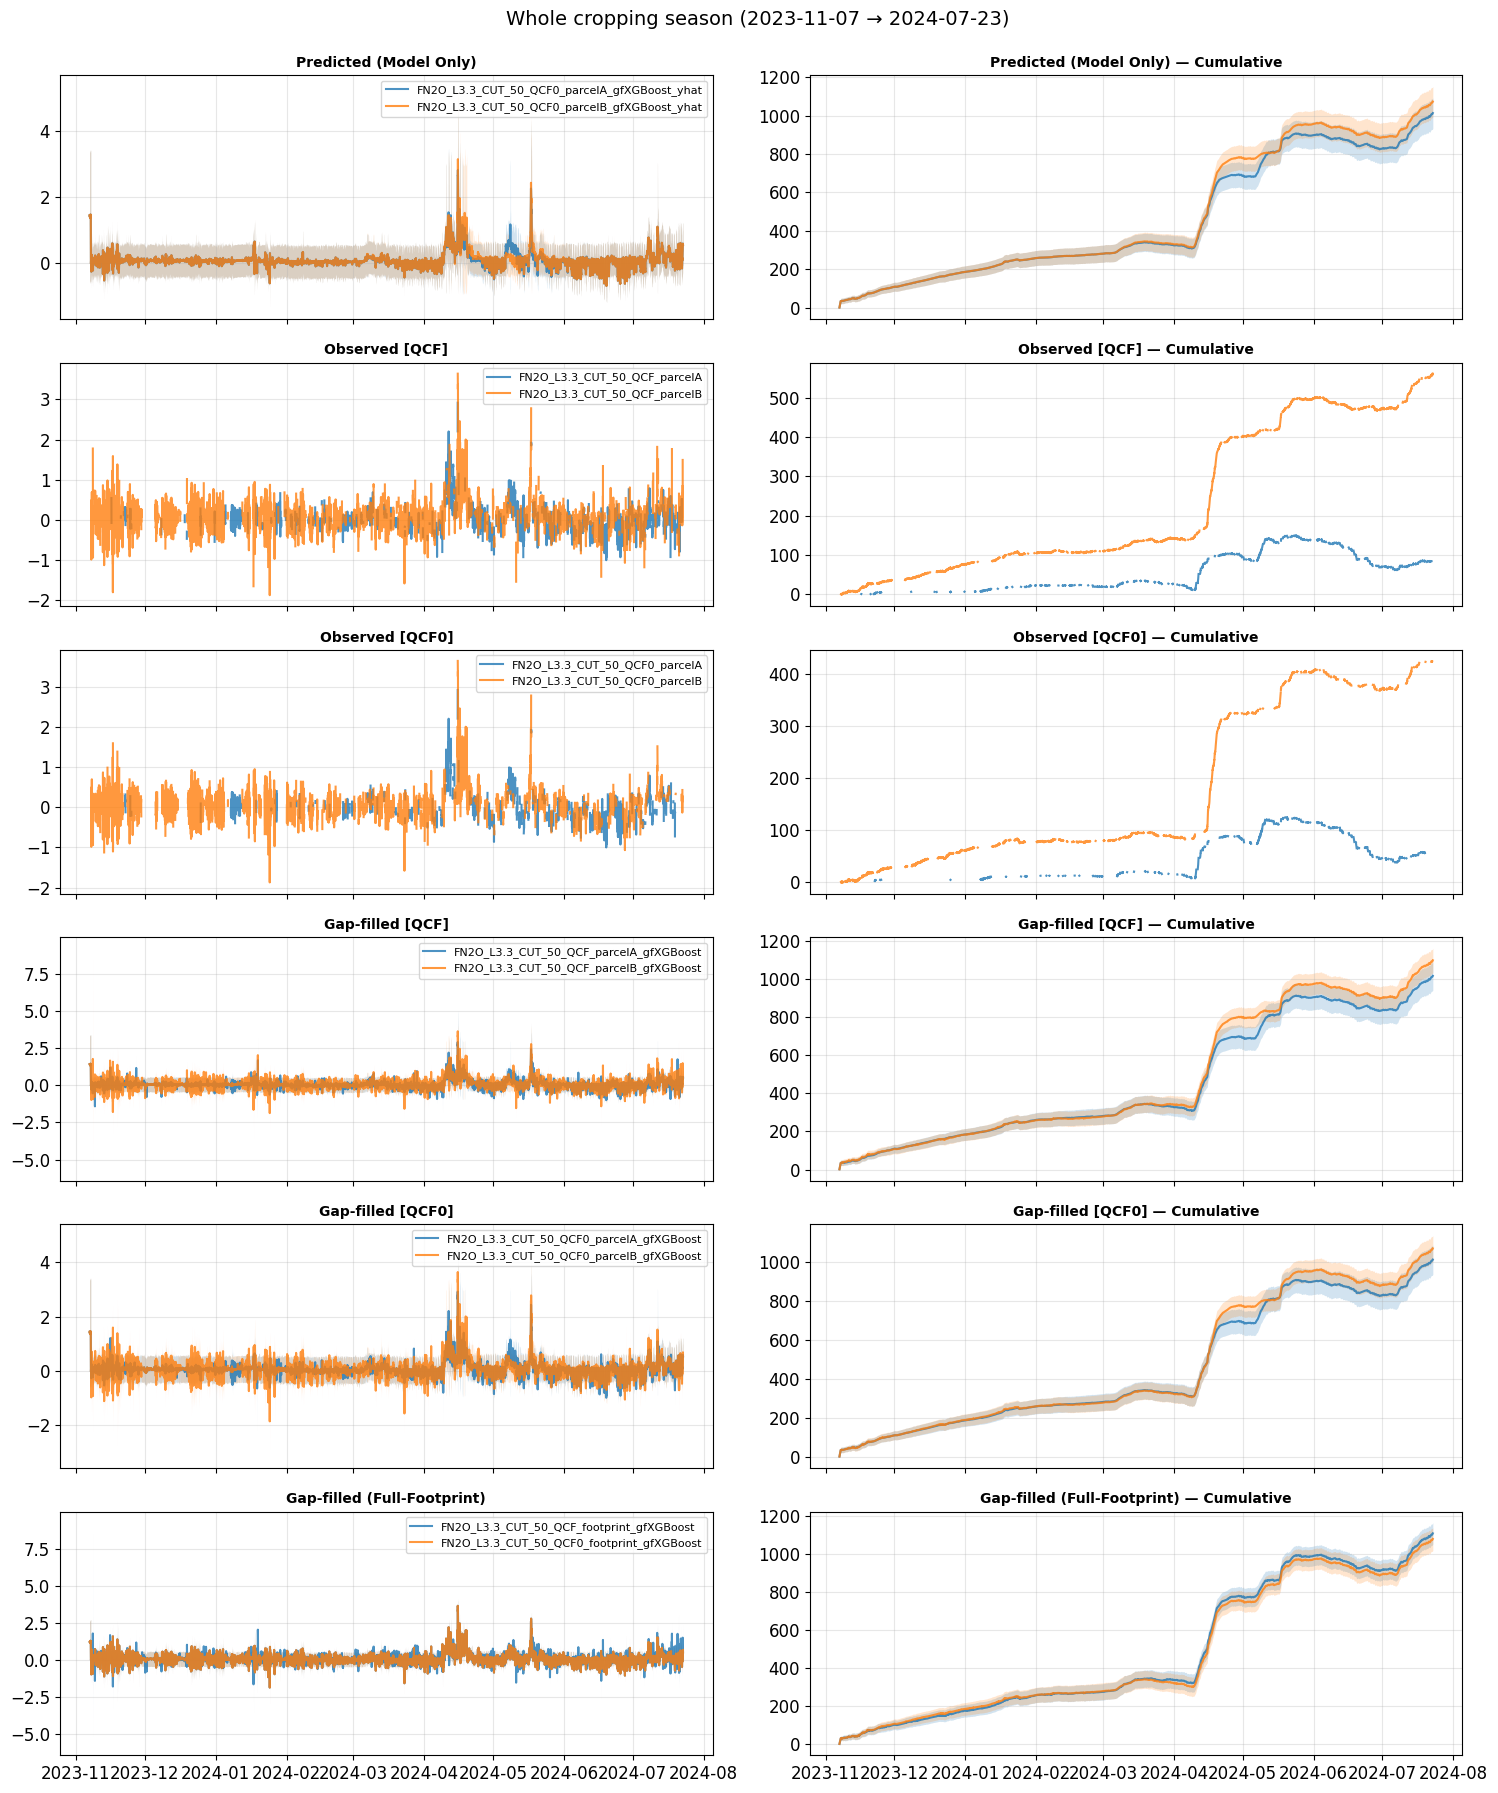

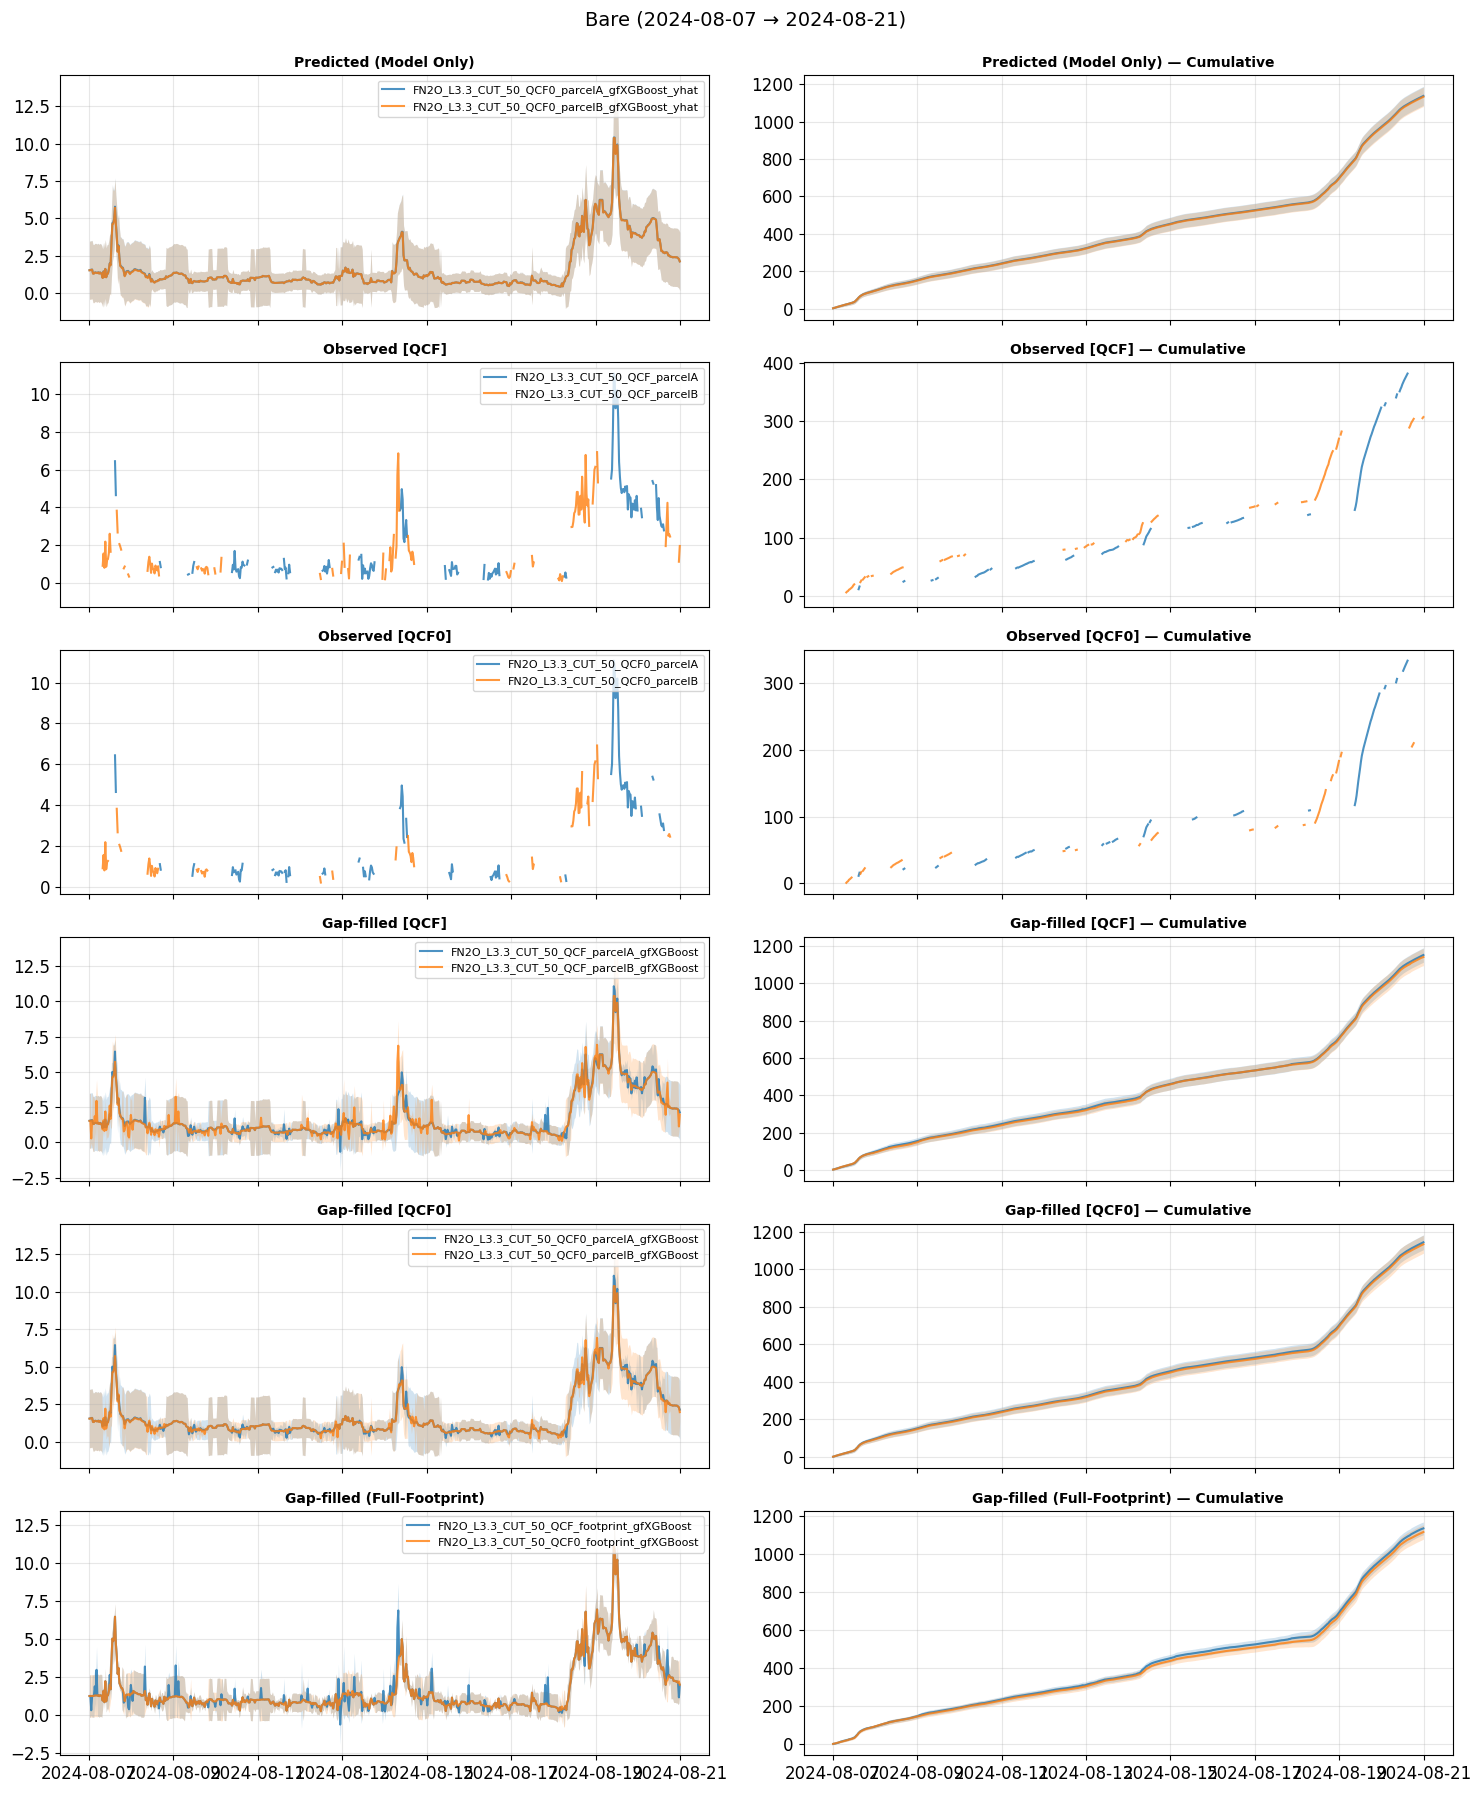

In [11]:
# Setup Views
df_fp = maindf.copy()
df_A  = build_df_for_parcel(maindf, TARGET_FLUX, "A", selected_features, add_trt=ADD_TRT)
df_B  = build_df_for_parcel(maindf, TARGET_FLUX, "B", selected_features, add_trt=ADD_TRT)
views = [
    ("parcelA", df_A, apply_gapfill_ts(df_A, fit), fit),
    ("parcelB", df_B, apply_gapfill_ts(df_B, fit), fit),
]
# Add the Footprint view
if PARCEL_CERTAIN:
    # If we trained a specific model for the footprint, use it
    views.append(("footprint", df_fp, apply_gapfill_ts(df_fp, fit_footprint), fit_footprint))
else:
    # Otherwise, apply the only model we have
    views.append(("footprint", df_fp, apply_gapfill_ts(df_fp, fit), fit))

# Merge Results
df_final, contexts = merge_gapfill_results(
    main_df=maindf,
    views=views,
    target_flux=TARGET_FLUX,      # e.g. "FN2O"
    target=TARGET,
    model_type=MODEL_TYPE,        # e.g. "XGBoost"
    ustar_cut=USTAR_CUT,           # e.g. "CUT_50"
    random_err_col=RAND_ERR_COL
)

# Plot Results
periods = [
    ("2023-11-07", "2024-07-23", "Whole cropping season"),
    ("2024-08-07", "2024-08-21", "Bare")
]
plot_gapfill_dashboard(
    df=df_final,
    periods=periods,
    target_flux=TARGET_FLUX,
    target=TARGET,
    model_type=MODEL_TYPE,
    ustar_cut=USTAR_CUT,
    contexts=contexts
)

# Create a copy of the final dataframe for CUT50
df_CUT50 = df_final.copy()


### SHAP CHECK

100%|===================| 11438/11448 [06:09<00:00]        

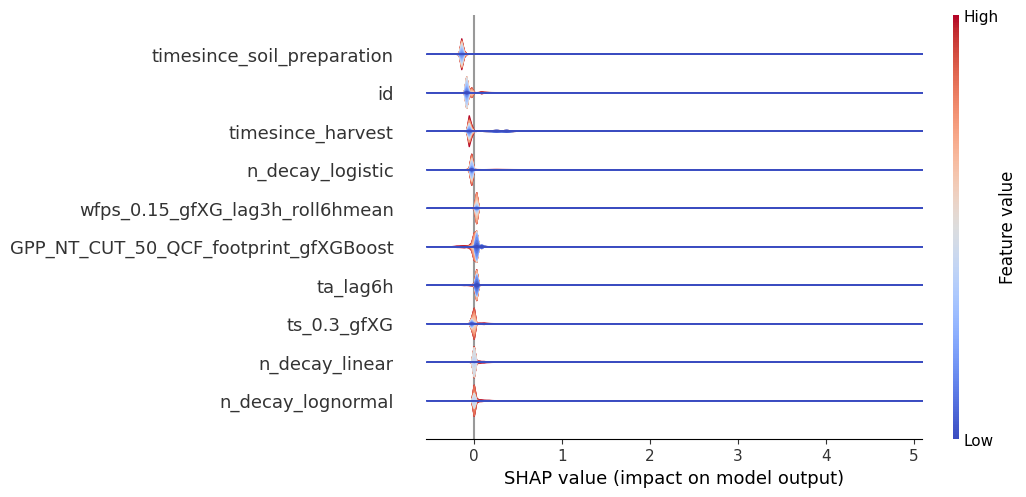

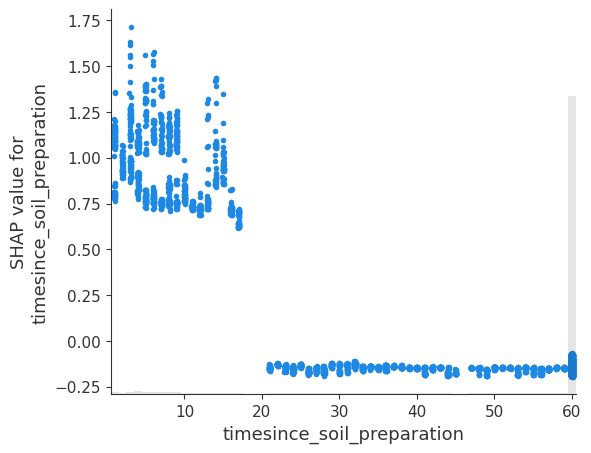

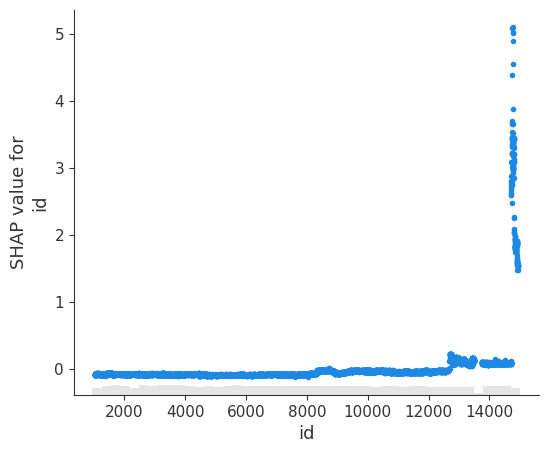

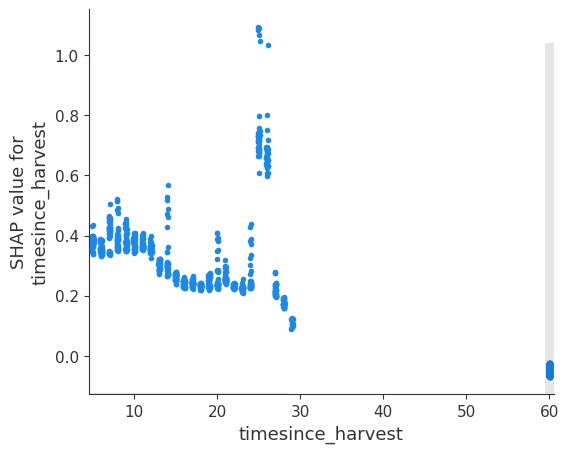

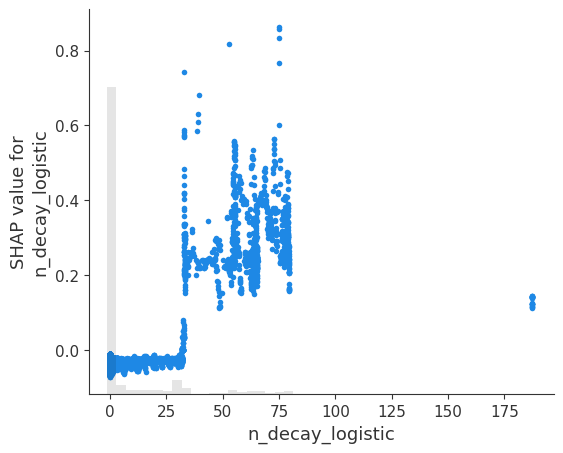

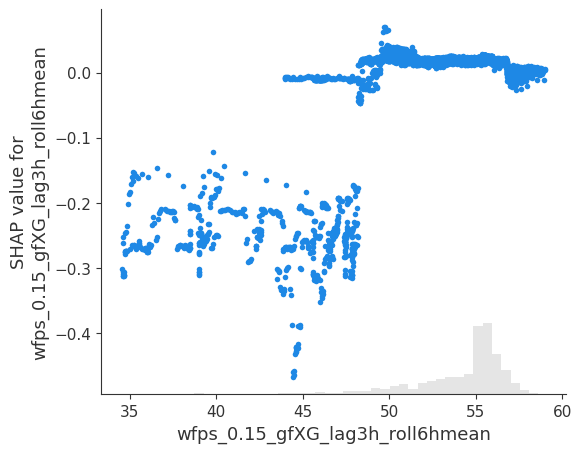

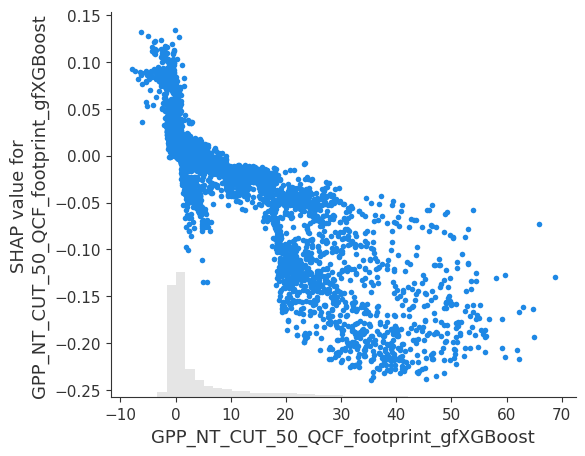

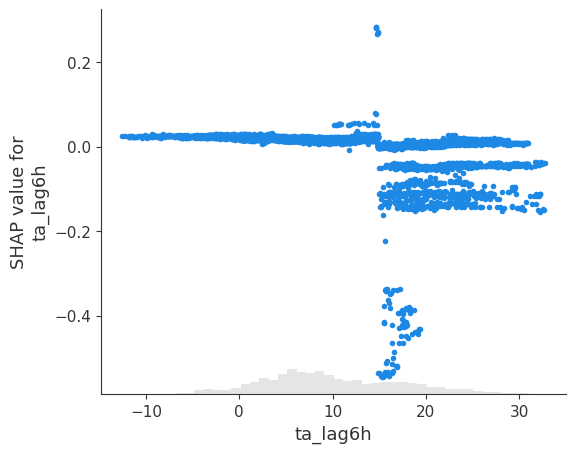

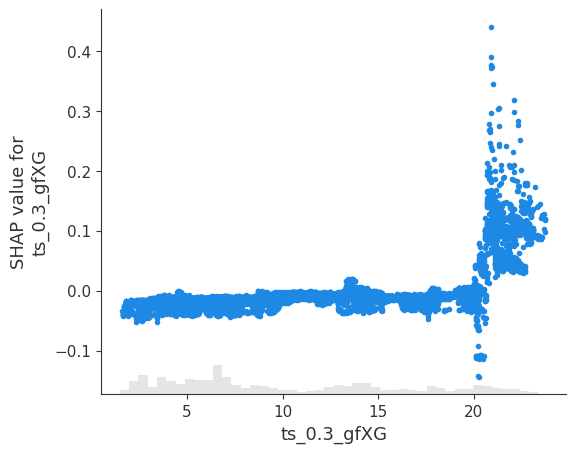

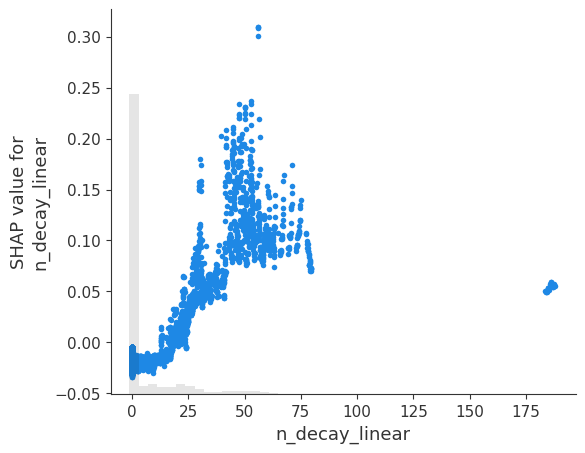

In [12]:
if SHAP_CHECK:

    # Initialize the SHAP explainer
    X = data_main[selected_features]
    explainer = shap.TreeExplainer(fit.model_final, data=X)

    # Calculate SHAP values
    shap_values = explainer(X, check_additivity=True)

    # Violin summary plot for top 10 features
    shap.plots.violin(shap_values, features=X, plot_type="layered_violin", max_display=10)
    plt.show()

    # Scatter plots of top 10 most important features
    for i in range(-1, -10, -1):
        shap.plots.scatter(shap_values[:, shap_values.abs.mean(0).argsort[i]])
        plt.show()

## CUT-84

In [13]:
USTAR_CUT = 'CUT_84'
TARGET = f'{TARGET_FLUX}_L3.3_{USTAR_CUT}_QCF0'
print(f'The target variable is {TARGET}')

The target variable is FN2O_L3.3_CUT_84_QCF0


### MODEL TRAINING

Started training of the gapfilling model and compute gapfilling uncertainty...
  Gap distribution: fitted mixture (cvm distance 13.3320; raw baseline 15.5798)
CV Strategy: artificial gaps in real time; 20 splits; test fractions 0.100-0.103
  Coverage: 510/4535 rows never held out (11.2%); mean times held out 2.01


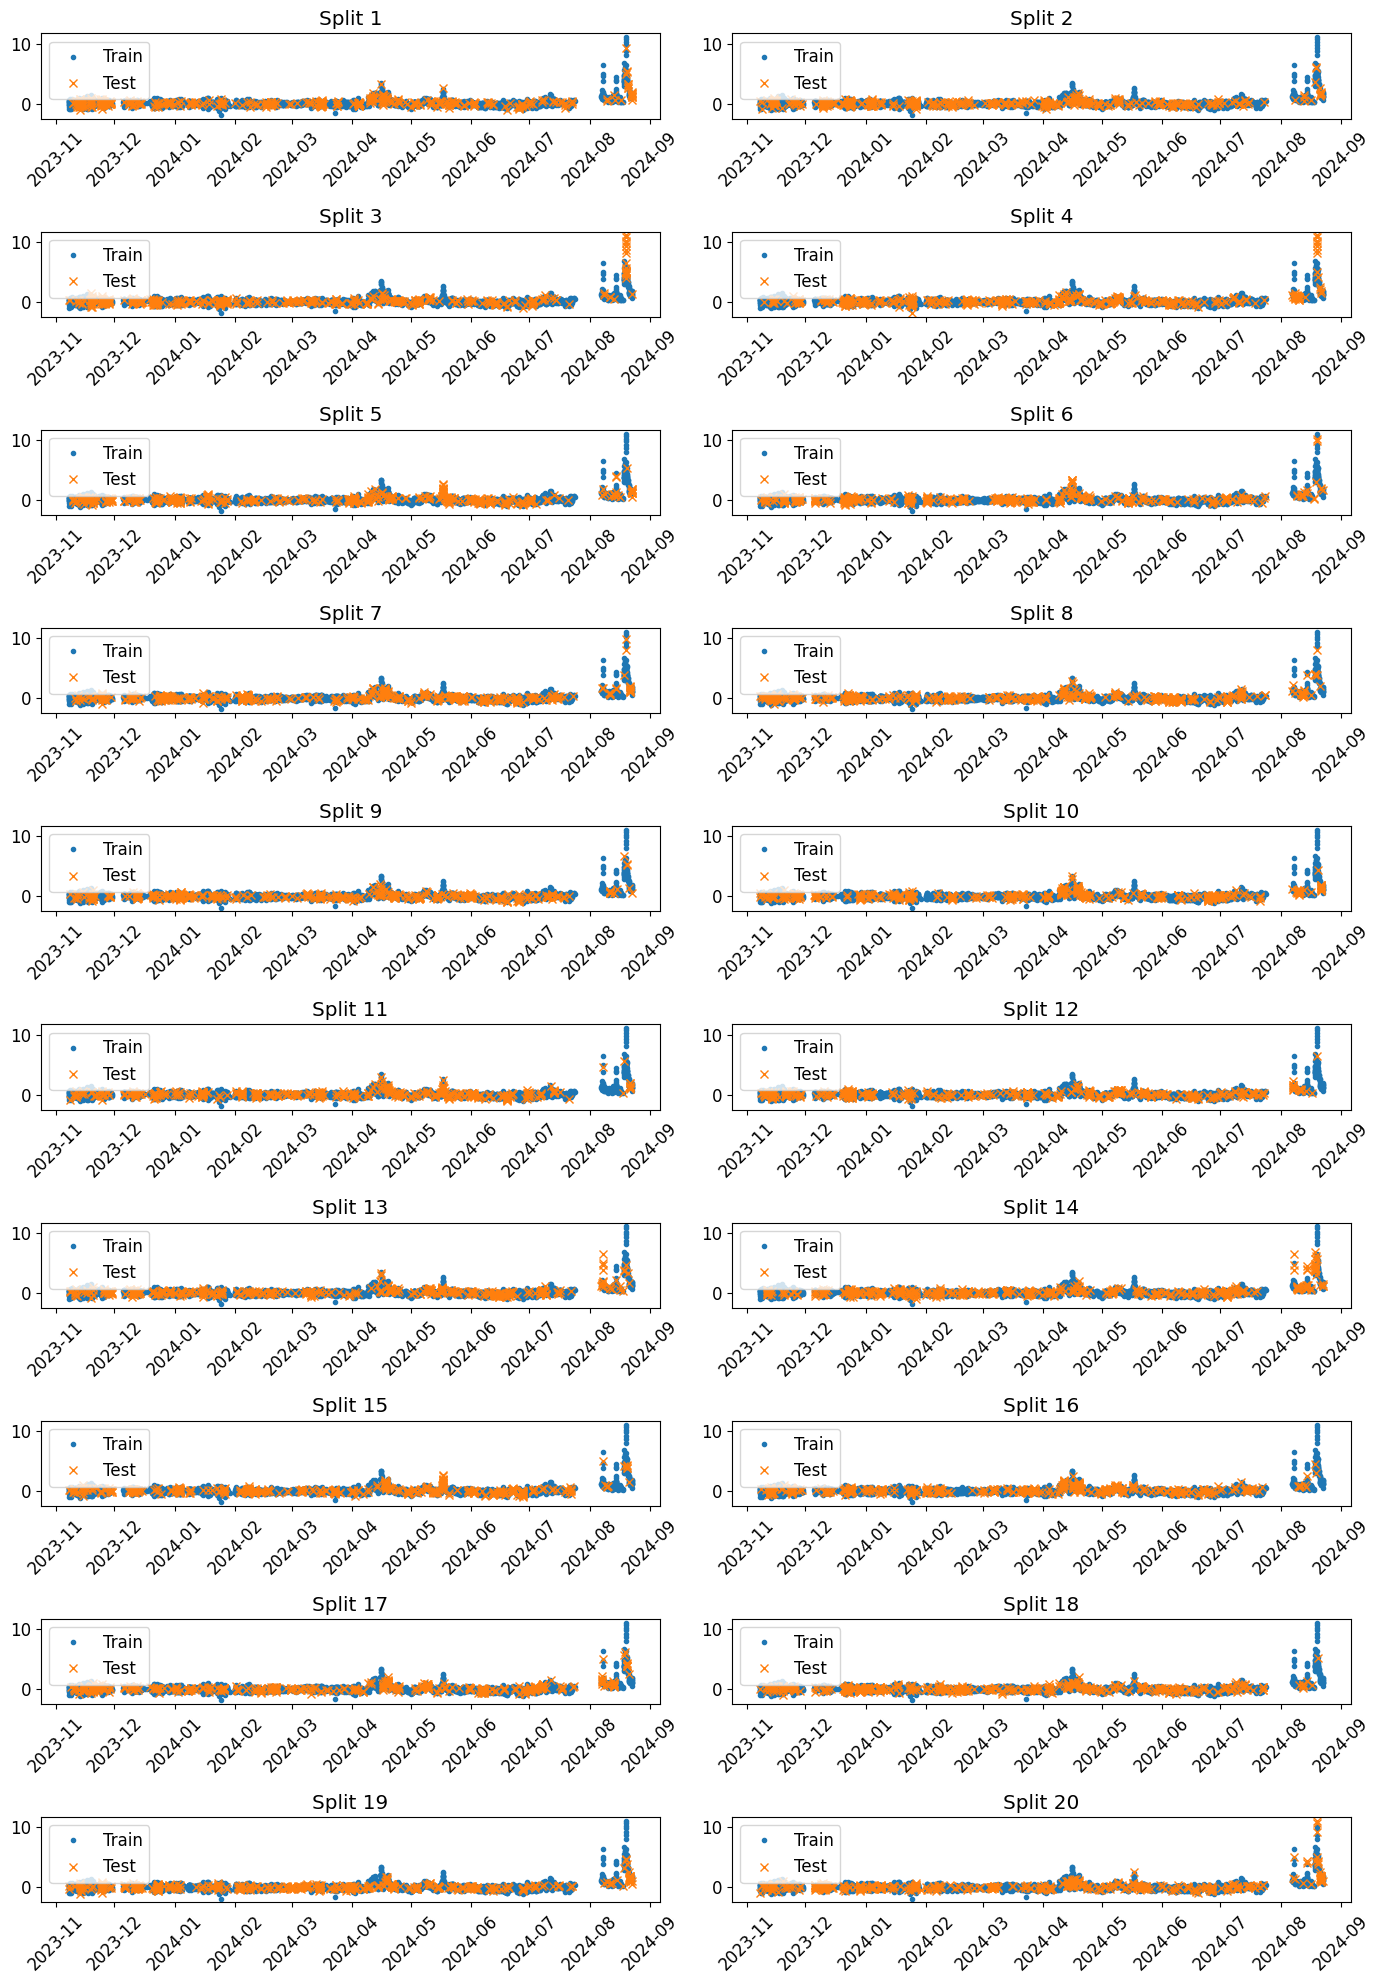

Training CV Ensemble (20 folds) & generating OOF predictions...
----------------------------------------
Gapfilling performance (mean across CV folds):
  Target: FN2O_L3.3_CUT_84_QCF0
  RMSE:   0.3804
  MAE:    0.2339
  R2:     0.7296
----------------------------------------
Fitting final model on full training set...


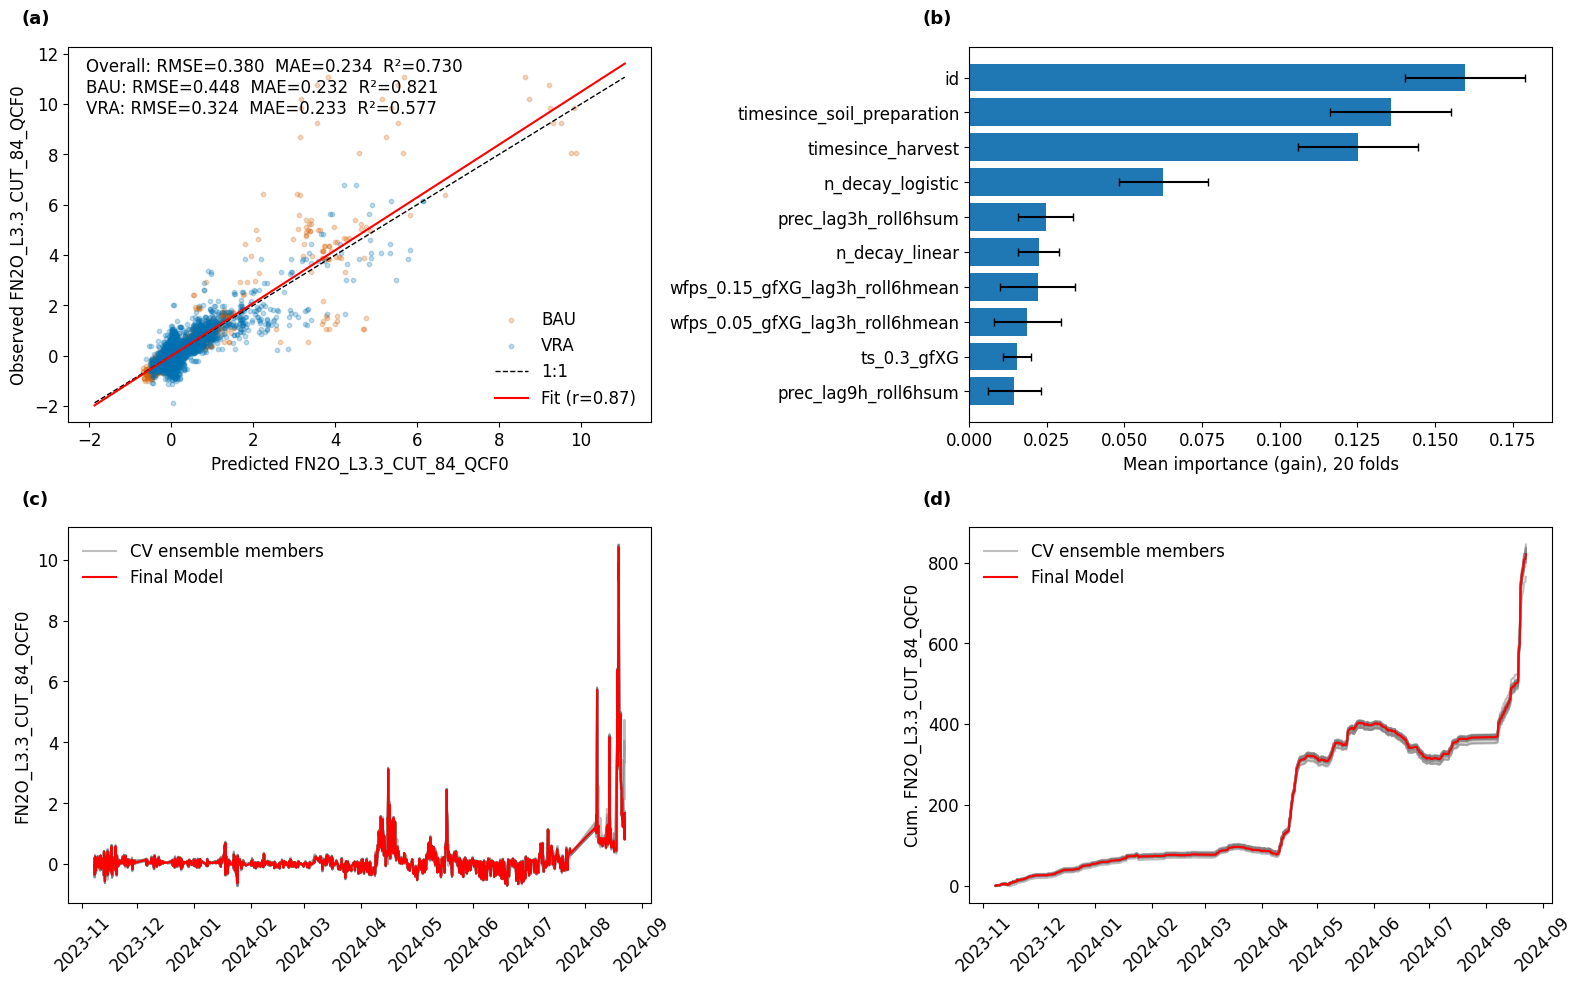

Finished training. Ensemble size (folds): 20

Started training of the gapfilling model for the full footprint and compute gapfilling uncertainty...
  Gap distribution: fitted mixture (cvm distance 16.2098; raw baseline 20.0456)
CV Strategy: artificial gaps in real time; 20 splits; test fractions 0.100-0.103
  Coverage: 606/5114 rows never held out (11.8%); mean times held out 2.02
Training CV Ensemble (20 folds) & generating OOF predictions...
----------------------------------------
Gapfilling performance (mean across CV folds):
  Target: FN2O_L3.3_CUT_84_QCF0
  RMSE:   0.3521
  MAE:    0.2252
  R2:     0.7557
----------------------------------------
Fitting final model on full training set...
Finished training. Ensemble size (folds): 20


In [14]:
# Train ONE model to gapfill --> we train only one model for both parcels and both QCF and QCF0
print("Started training of the gapfilling model and compute gapfilling uncertainty...")
fit = fit_gapfill_ts(
    data_main,
    target_col=TARGET,
    feature_cols=selected_features,
    model_factory=model_factory,
    log_transform=LOG_TRANSFORM,
    undersample=UNDERSAMPLE,
)
print(f"Finished training. Ensemble size (folds): {len(fit.ensemble_models)}")

# Train ONE model to gapfill the footprint if only confident assignments were used before
if PARCEL_CERTAIN:
    # we train only one model for both parcels and both QCF and QCF0
    print("\nStarted training of the gapfilling model for the full footprint and compute gapfilling uncertainty...")
    fit_footprint = fit_gapfill_ts(
        maindf,
        target_col=TARGET,
        feature_cols=selected_features,
        model_factory=model_factory,
        log_transform=LOG_TRANSFORM,
        undersample=UNDERSAMPLE,
        plot=False
    )
    print(f"Finished training. Ensemble size (folds): {len(fit_footprint.ensemble_models)}")


### GAPFILLING

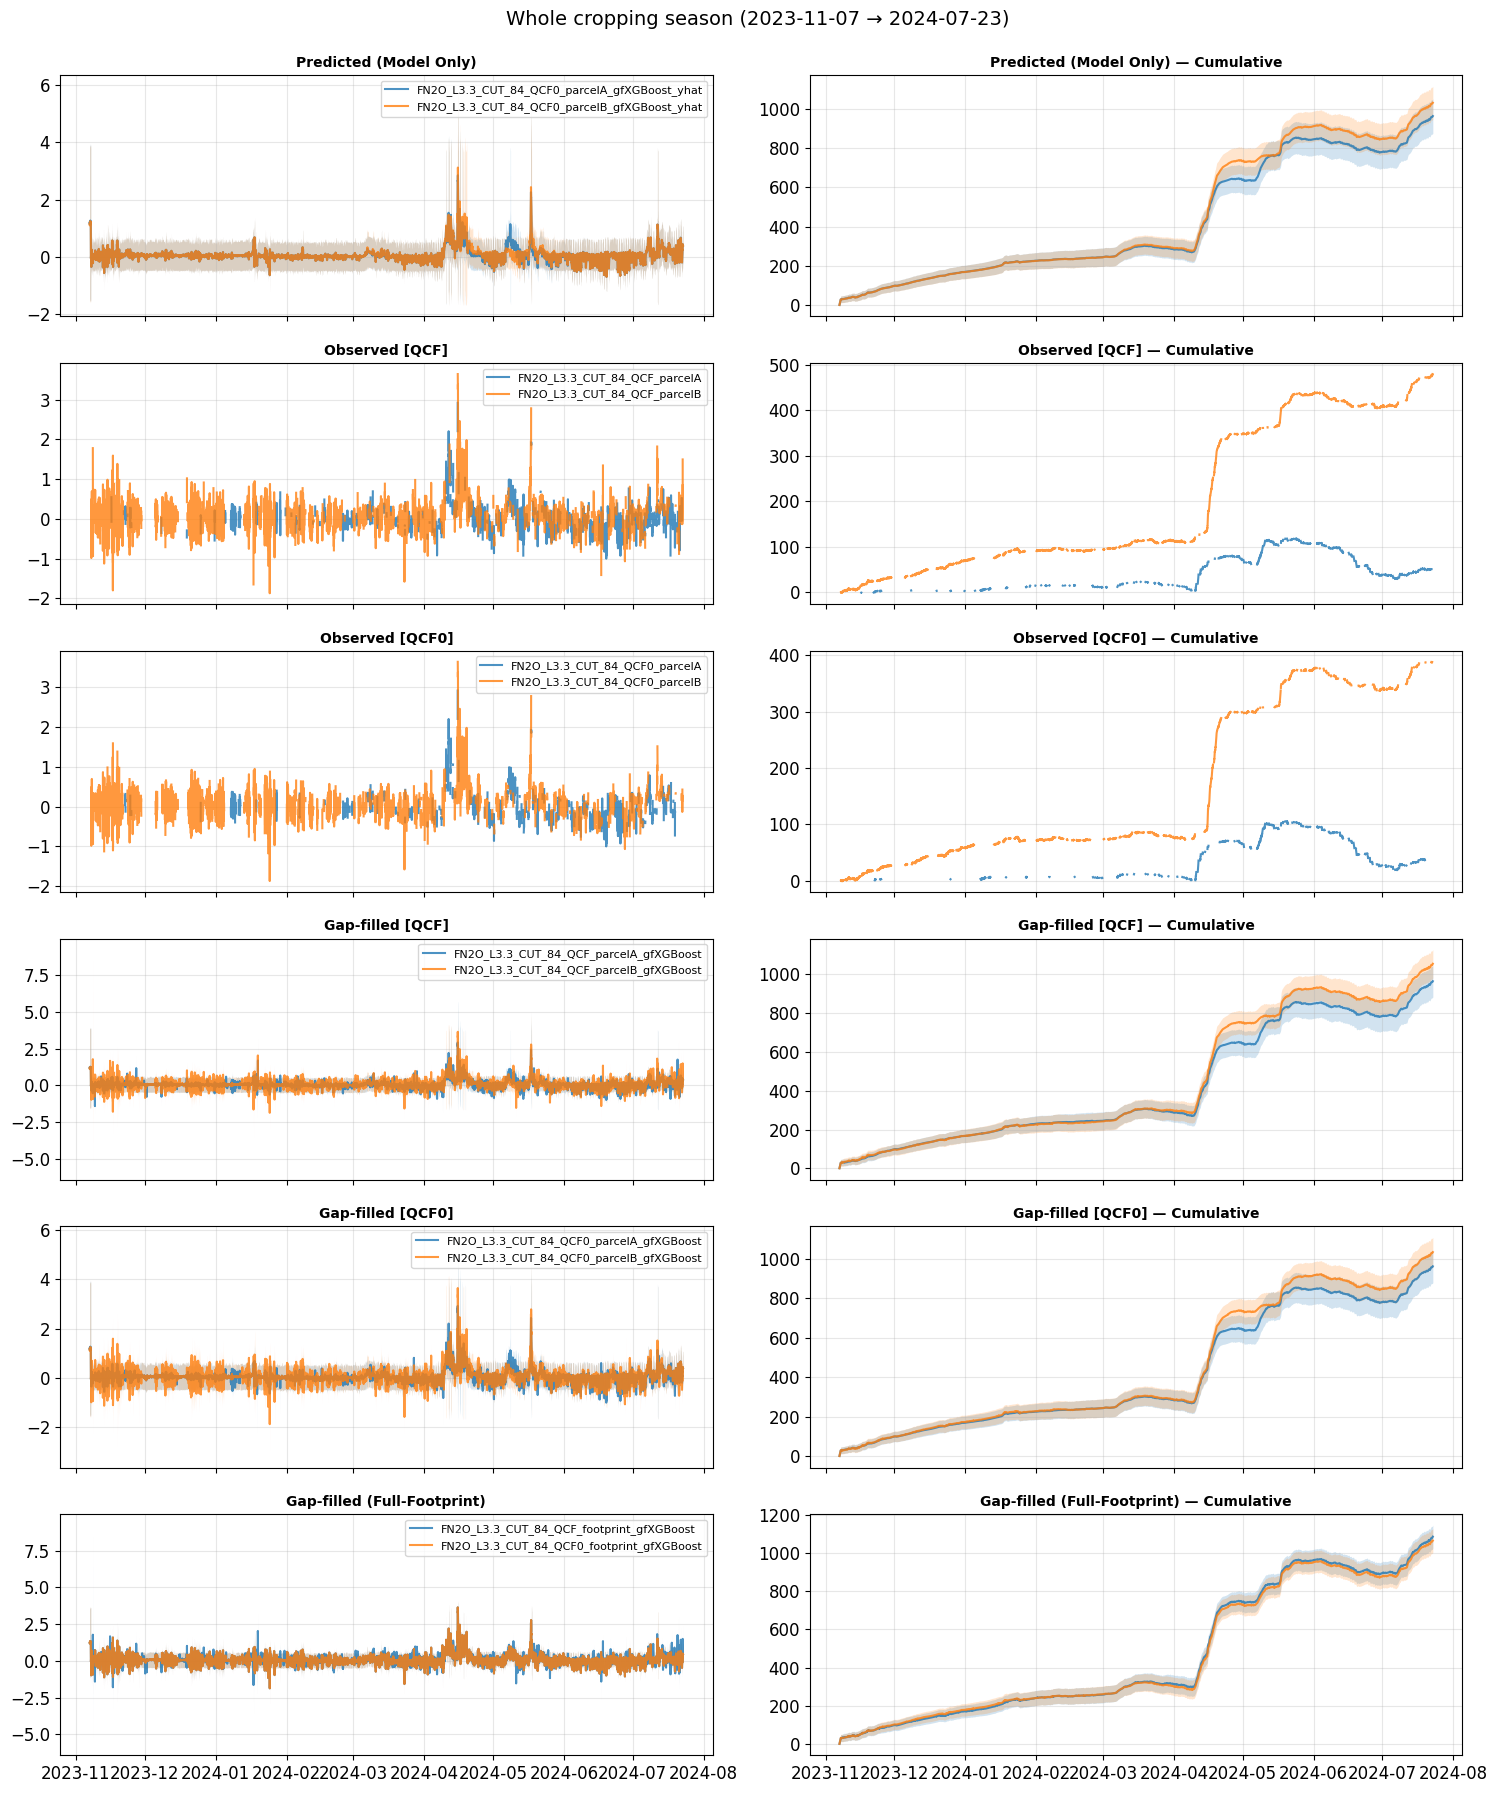

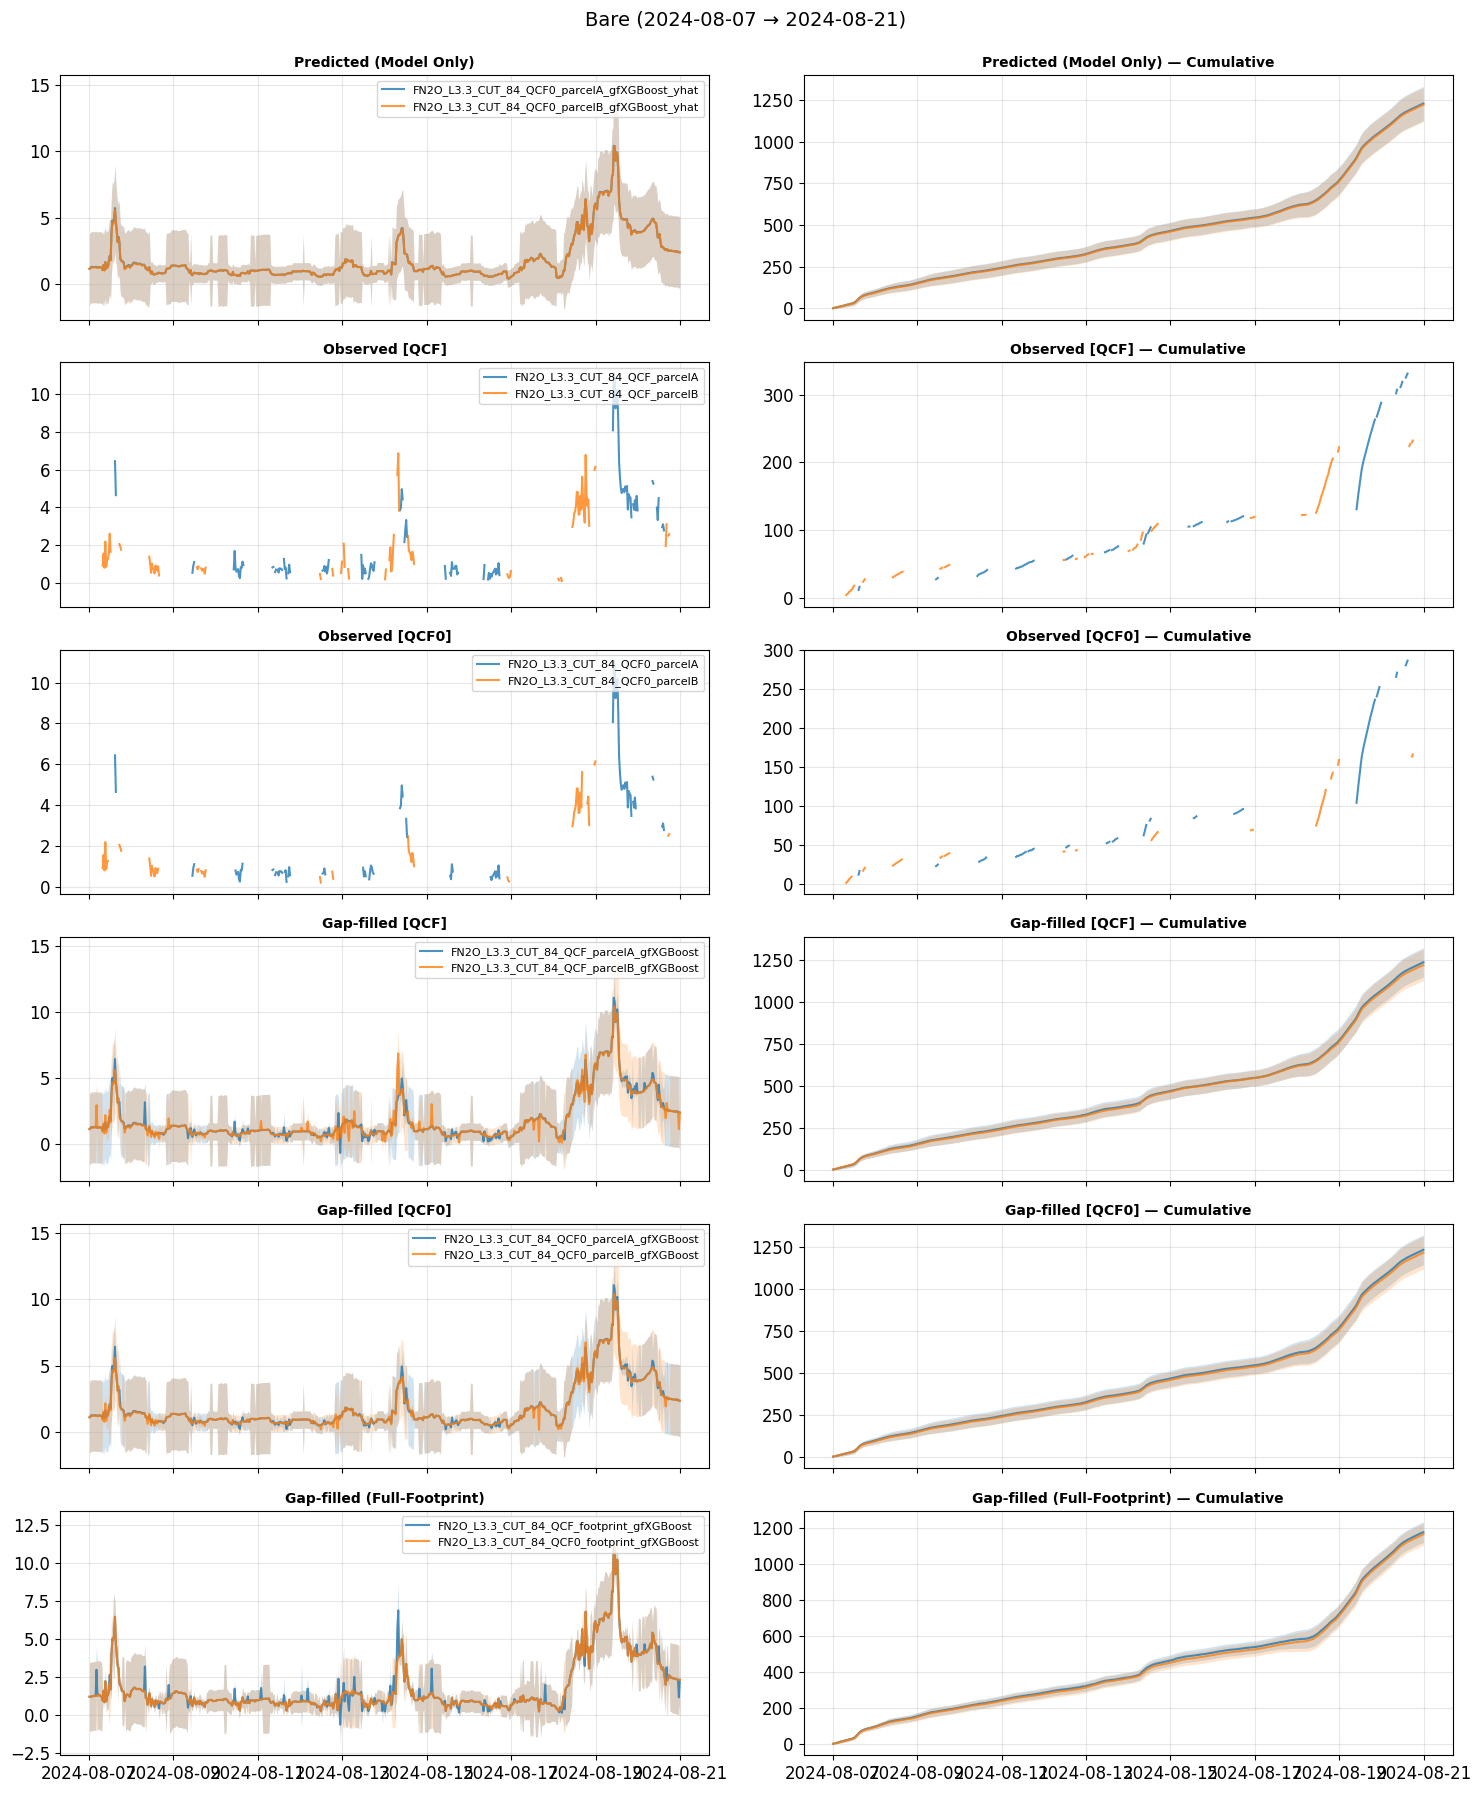

In [15]:
# Setup Views
df_fp = maindf.copy()
df_A  = build_df_for_parcel(maindf, TARGET_FLUX, "A", selected_features, add_trt=ADD_TRT)
df_B  = build_df_for_parcel(maindf, TARGET_FLUX, "B", selected_features, add_trt=ADD_TRT)
views = [
    ("parcelA", df_A, apply_gapfill_ts(df_A, fit), fit),
    ("parcelB", df_B, apply_gapfill_ts(df_B, fit), fit),
]
# Add the Footprint view
if PARCEL_CERTAIN:
    # If we trained a specific model for the footprint, use it
    views.append(("footprint", df_fp, apply_gapfill_ts(df_fp, fit_footprint), fit_footprint))
else:
    # Otherwise, apply the only model we have
    views.append(("footprint", df_fp, apply_gapfill_ts(df_fp, fit), fit))

# Merge Results
df_final, contexts = merge_gapfill_results(
    main_df=maindf,
    views=views,
    target_flux=TARGET_FLUX,      # e.g. "FN2O"
    target=TARGET,
    model_type=MODEL_TYPE,        # e.g. "XGBoost"
    ustar_cut=USTAR_CUT,           # e.g. "CUT_50"
    random_err_col=RAND_ERR_COL
)

# Plot Results
periods = [
    ("2023-11-07", "2024-07-23", "Whole cropping season"),
    ("2024-08-07", "2024-08-21", "Bare")
]
plot_gapfill_dashboard(
    df=df_final,
    periods=periods,
    target_flux=TARGET_FLUX,
    target=TARGET,
    model_type=MODEL_TYPE,
    ustar_cut=USTAR_CUT,
    contexts=contexts
)

# Create a copy of the final dataframe for CUT84
df_CUT84 = df_final.copy()


# MERGE RESULTS

In [16]:
newcols_CUT16 = [c for c in df_CUT16.columns if c not in maindf]
print(f"NEW VARIABLES FROM GAP-FILLING {TARGET}:")
display(newcols_CUT16)

newcols_CUT50 = [c for c in df_CUT50.columns if c not in maindf]
print(f"NEW VARIABLES FROM GAP-FILLING {TARGET}:")  
display(newcols_CUT50)

newcols_CUT84 = [c for c in df_CUT84.columns if c not in maindf]
print(f"NEW VARIABLES FROM GAP-FILLING {TARGET}:")     
display(newcols_CUT84)

# Merge the new columns into a single dataframe
gapfilled_df = pd.concat([df_CUT16[newcols_CUT16], df_CUT50[newcols_CUT50], df_CUT84[newcols_CUT84]], axis=1)

gapfilled_df

NEW VARIABLES FROM GAP-FILLING FN2O_L3.3_CUT_84_QCF0:


['FN2O_L3.3_CUT_16_QCF_parcelA',
 'FN2O_L3.3_CUT_16_QCF_parcelA_gfXGBoost_yhat',
 'FN2O_L3.3_CUT_16_QCF_parcelA_gfXGBoost',
 'FLAG_FN2O_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ISFILLED',
 'FN2O_L3.3_CUT_16_QCF_parcelA_gfXGBoost_sigmaGF',
 'FN2O_L3.3_CUT_16_QCF_parcelA_gfXGBoost_sigmaResid',
 'FN2O_L3.3_CUT_16_QCF_parcelA_gfXGBoost_sigmaEns',
 'FN2O_L3.3_CUT_16_QCF_parcelA_gfXGBoost_total_unc',
 'FN2O_L3.3_CUT_16_QCF_parcelA_gfXGBoost_sigmaObs',
 'FN2O_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens00',
 'FN2O_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens01',
 'FN2O_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens02',
 'FN2O_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens03',
 'FN2O_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens04',
 'FN2O_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens05',
 'FN2O_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens06',
 'FN2O_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens07',
 'FN2O_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens08',
 'FN2O_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens09',
 'FN2O_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens10',
 'FN2O_L3.3_CUT_16

NEW VARIABLES FROM GAP-FILLING FN2O_L3.3_CUT_84_QCF0:


['FN2O_L3.3_CUT_50_QCF_parcelA',
 'FN2O_L3.3_CUT_50_QCF_parcelA_gfXGBoost_yhat',
 'FN2O_L3.3_CUT_50_QCF_parcelA_gfXGBoost',
 'FLAG_FN2O_L3.3_CUT_50_QCF_parcelA_gfXGBoost_ISFILLED',
 'FN2O_L3.3_CUT_50_QCF_parcelA_gfXGBoost_sigmaGF',
 'FN2O_L3.3_CUT_50_QCF_parcelA_gfXGBoost_sigmaResid',
 'FN2O_L3.3_CUT_50_QCF_parcelA_gfXGBoost_sigmaEns',
 'FN2O_L3.3_CUT_50_QCF_parcelA_gfXGBoost_total_unc',
 'FN2O_L3.3_CUT_50_QCF_parcelA_gfXGBoost_sigmaObs',
 'FN2O_L3.3_CUT_50_QCF_parcelA_gfXGBoost_ens00',
 'FN2O_L3.3_CUT_50_QCF_parcelA_gfXGBoost_ens01',
 'FN2O_L3.3_CUT_50_QCF_parcelA_gfXGBoost_ens02',
 'FN2O_L3.3_CUT_50_QCF_parcelA_gfXGBoost_ens03',
 'FN2O_L3.3_CUT_50_QCF_parcelA_gfXGBoost_ens04',
 'FN2O_L3.3_CUT_50_QCF_parcelA_gfXGBoost_ens05',
 'FN2O_L3.3_CUT_50_QCF_parcelA_gfXGBoost_ens06',
 'FN2O_L3.3_CUT_50_QCF_parcelA_gfXGBoost_ens07',
 'FN2O_L3.3_CUT_50_QCF_parcelA_gfXGBoost_ens08',
 'FN2O_L3.3_CUT_50_QCF_parcelA_gfXGBoost_ens09',
 'FN2O_L3.3_CUT_50_QCF_parcelA_gfXGBoost_ens10',
 'FN2O_L3.3_CUT_50

NEW VARIABLES FROM GAP-FILLING FN2O_L3.3_CUT_84_QCF0:


['FN2O_L3.3_CUT_84_QCF_parcelA',
 'FN2O_L3.3_CUT_84_QCF_parcelA_gfXGBoost_yhat',
 'FN2O_L3.3_CUT_84_QCF_parcelA_gfXGBoost',
 'FLAG_FN2O_L3.3_CUT_84_QCF_parcelA_gfXGBoost_ISFILLED',
 'FN2O_L3.3_CUT_84_QCF_parcelA_gfXGBoost_sigmaGF',
 'FN2O_L3.3_CUT_84_QCF_parcelA_gfXGBoost_sigmaResid',
 'FN2O_L3.3_CUT_84_QCF_parcelA_gfXGBoost_sigmaEns',
 'FN2O_L3.3_CUT_84_QCF_parcelA_gfXGBoost_total_unc',
 'FN2O_L3.3_CUT_84_QCF_parcelA_gfXGBoost_sigmaObs',
 'FN2O_L3.3_CUT_84_QCF_parcelA_gfXGBoost_ens00',
 'FN2O_L3.3_CUT_84_QCF_parcelA_gfXGBoost_ens01',
 'FN2O_L3.3_CUT_84_QCF_parcelA_gfXGBoost_ens02',
 'FN2O_L3.3_CUT_84_QCF_parcelA_gfXGBoost_ens03',
 'FN2O_L3.3_CUT_84_QCF_parcelA_gfXGBoost_ens04',
 'FN2O_L3.3_CUT_84_QCF_parcelA_gfXGBoost_ens05',
 'FN2O_L3.3_CUT_84_QCF_parcelA_gfXGBoost_ens06',
 'FN2O_L3.3_CUT_84_QCF_parcelA_gfXGBoost_ens07',
 'FN2O_L3.3_CUT_84_QCF_parcelA_gfXGBoost_ens08',
 'FN2O_L3.3_CUT_84_QCF_parcelA_gfXGBoost_ens09',
 'FN2O_L3.3_CUT_84_QCF_parcelA_gfXGBoost_ens10',
 'FN2O_L3.3_CUT_84

,FN2O_L3.3_CUT_16_QCF_parcelA,FN2O_L3.3_CUT_16_QCF_parcelA_gfXGBoost_yhat,FN2O_L3.3_CUT_16_QCF_parcelA_gfXGBoost,FLAG_FN2O_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ISFILLED,FN2O_L3.3_CUT_16_QCF_parcelA_gfXGBoost_sigmaGF,FN2O_L3.3_CUT_16_QCF_parcelA_gfXGBoost_sigmaResid,FN2O_L3.3_CUT_16_QCF_parcelA_gfXGBoost_sigmaEns,FN2O_L3.3_CUT_16_QCF_parcelA_gfXGBoost_total_unc,FN2O_L3.3_CUT_16_QCF_parcelA_gfXGBoost_sigmaObs,FN2O_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens00,FN2O_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens01,FN2O_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens02,FN2O_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens03,FN2O_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens04,FN2O_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens05,...,FN2O_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens05,FN2O_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens06,FN2O_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens07,FN2O_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens08,FN2O_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens09,FN2O_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens10,FN2O_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens11,FN2O_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens12,FN2O_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens13,FN2O_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens14,FN2O_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens15,FN2O_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens16,FN2O_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens17,FN2O_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens18,FN2O_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens19
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-10-17 00:15:00,NaN,0.508736,0.508736,1,0.286058,0.259769,0.119787,0.286058,NaN,0.580012,0.312697,0.813646,0.554244,0.581467,0.529725,...,0.735697,0.459464,0.931877,0.822733,0.482238,0.689521,0.942653,0.651730,1.054811,1.335557,2.220159,0.711464,0.490036,0.974116,0.953533
2023-10-17 00:45:00,NaN,0.508736,0.508736,1,0.286115,0.259769,0.119923,0.286115,NaN,0.580012,0.312697,0.813646,0.553431,0.581467,0.529725,...,0.738177,0.459464,0.931877,0.822733,0.482238,0.689521,0.942653,0.651177,1.083937,1.335557,2.220159,0.711464,0.490036,0.974116,0.953533
2023-10-17 01:15:00,NaN,0.508736,0.508736,1,0.286154,0.259769,0.120016,0.286154,NaN,0.582658,0.312697,0.818717,0.556441,0.578896,0.529725,...,0.735425,0.459464,0.931877,0.820188,0.482238,0.689521,0.942653,0.650526,1.083937,1.332362,2.220159,0.708140,0.490036,0.974116,0.953533
2023-10-17 01:45:00,NaN,0.508736,0.508736,1,0.286146,0.259769,0.119997,0.286146,NaN,0.582658,0.312697,0.818717,0.556441,0.578896,0.530681,...,0.735425,0.459464,0.931877,0.820188,0.482238,0.691826,0.942653,0.650526,1.083937,1.332362,2.220159,0.708140,0.490036,0.971786,0.953533
2023-10-17 02:15:00,NaN,0.510066,0.510066,1,0.286163,0.259769,0.120037,0.286163,NaN,0.583404,0.312697,0.822797,0.551156,0.578896,0.527444,...,0.735425,0.459464,0.931877,0.820188,0.480573,0.691826,0.942653,0.650526,1.085782,1.332362,2.220159,0.711668,0.490036,0.975464,0.953533
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-22 21:45:00,NaN,1.038187,1.038187,1,0.733952,0.713755,0.170991,0.733952,NaN,0.844176,0.959333,0.939193,1.128340,1.417385,0.980693,...,1.218109,1.704006,1.428533,1.481580,1.504656,1.697986,1.775646,2.401844,1.637867,1.560626,1.346652,1.506102,1.429332,1.755173,1.297038
2024-08-22 22:15:00,NaN,1.032128,1.032128,1,0.730727,0.713755,0.156572,0.730727,NaN,0.868732,0.929215,0.928889,1.148329,1.398074,0.984719,...,1.202015,1.588008,1.419005,1.491154,1.464738,1.646219,1.723047,2.397539,1.630084,1.363604,1.263779,1.407821,1.390754,1.650625,1.254816
2024-08-22 22:45:00,NaN,1.075634,1.075634,1,0.730503,0.713755,0.155522,0.730503,NaN,0.885278,0.959112,0.967923,1.156499,1.433057,0.993884,...,1.204991,1.567836,1.423643,1.511327,1.489906,1.647603,1.716027,2.413524,1.644758,1.361771,1.282362,1.418027,1.437943,1.740383,1.273254


Cumulative plots to check differences between CUT16, CUT50 and CUT84

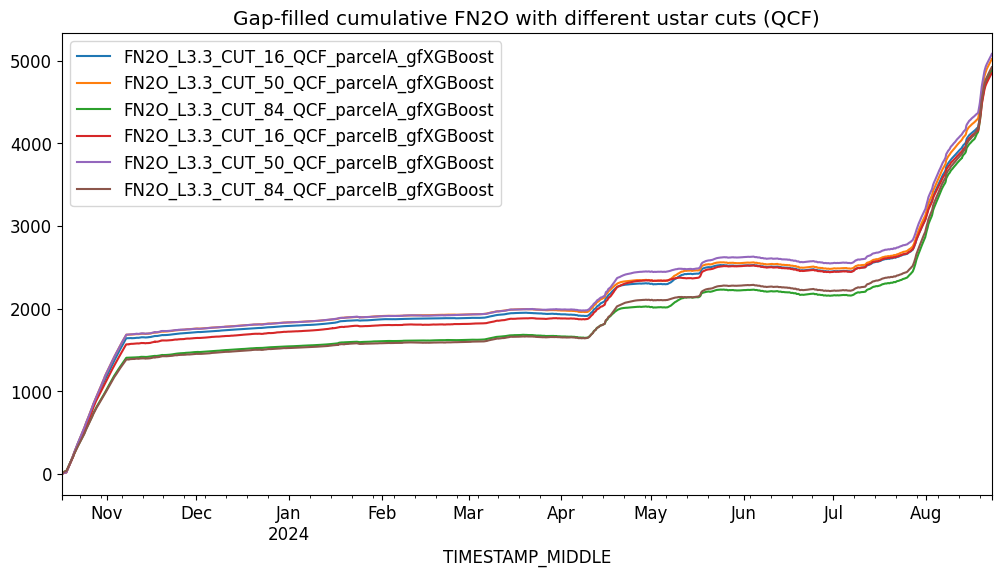

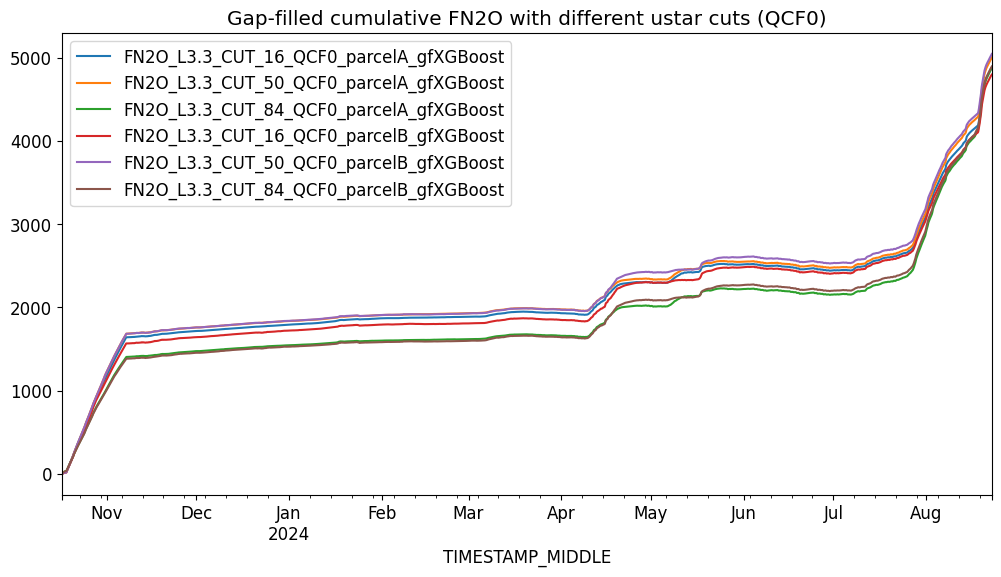

In [17]:
# Plot cumulative fluxes for different ustar cuts and QCF/QCF0
for qcf in ['QCF', 'QCF0']:
    gapfilled_df[
        [
        f'{TARGET_FLUX}_L3.3_CUT_16_{qcf}_parcelA_gf{MODEL_TYPE}', 
        f'{TARGET_FLUX}_L3.3_CUT_50_{qcf}_parcelA_gf{MODEL_TYPE}', 
        f'{TARGET_FLUX}_L3.3_CUT_84_{qcf}_parcelA_gf{MODEL_TYPE}',
        f'{TARGET_FLUX}_L3.3_CUT_16_{qcf}_parcelB_gf{MODEL_TYPE}', 
        f'{TARGET_FLUX}_L3.3_CUT_50_{qcf}_parcelB_gf{MODEL_TYPE}',
        f'{TARGET_FLUX}_L3.3_CUT_84_{qcf}_parcelB_gf{MODEL_TYPE}'
        ]].cumsum().plot(figsize=(12, 6), title=f'Gap-filled cumulative {TARGET_FLUX} with different ustar cuts ({qcf})')
    plt.show()

# EXPORT

In [18]:
filename = f"82.4.1_{TARGET_FLUX}_GF-{MODEL_TYPE}"
df_export = gapfilled_df.copy()
save_parquet(data=df_export, filename=filename)

Saved file 82.4.1_FN2O_GF-XGBoost.parquet (1.859 seconds).


'82.4.1_FN2O_GF-XGBoost.parquet'

# End of notebook

In [19]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished. {dt_string}")

Finished. 2026-09-23 19:59:03
